# Airbnb NYC Business EDA
## 에어비앤비 뉴욕 비즈니스 EDA

---

### Project Goal

**English**

This exploratory analysis follows a single connected storyline across four business
questions about the NYC Airbnb market:

1. **Market Segmentation** — where is revenue concentrated today?
2. **Growth Trend** — is that opportunity still growing?
3. **Risk Distribution** — what regulatory risk is hiding inside that growth?
4. **Priority Ranking** — who should the company act on first to manage that risk?

Each question is built on top of the finding from the previous one, so the four
questions read as a single decision journey rather than four separate analyses.
The notebook is designed to answer these questions **before** implementing the
production pipeline.

**한국어**

이 노트북은 뉴욕 Airbnb 시장에 대해 서로 연결된 하나의 스토리를 따라가는 4개의
비즈니스 질문에 답합니다.

1. **시장 세분화** — 지금 매출은 어디에 몰려 있는가?
2. **성장 추이** — 그 기회는 여전히 커지고 있는가?
3. **리스크 분포** — 그 성장 안에는 어떤 규제 리스크가 숨어 있는가?
4. **우선순위 비교** — 그 리스크를 해결하려면 누구부터 대응해야 하는가?

각 질문은 이전 질문의 결과를 이어받아 더 깊이 파고들도록 설계되어, 4개의 독립된
분석이 아니라 하나의 의사결정 여정처럼 읽힙니다. 실제 Pipeline을 구현하기 전에
데이터를 이해하고, 필요한 전처리를 결정하기 위한 목적입니다.

> **Note:** This notebook is NOT the final implementation.
> All validated logic will be moved into the `pipeline/` package later.
> 이 노트북은 최종 구현이 아닙니다. 검증된 로직은 나중에 `pipeline/` 패키지로 이동됩니다.

---
## Workflow
## 분석 흐름

**English**

Each business question follows the same structured workflow to ensure consistent and
well-documented analysis. For Business Questions 1–4, the core analysis is written
directly in **SQL** against `airbnb_nyc.sqlite`, so that each question clearly
demonstrates the SQL technique it is meant to practice (JOIN + GROUP BY, date
functions, CTE, window functions). Python (pandas / scipy) is then used on top of the
SQL result to run statistical checks and build charts.

**한국어**

각 비즈니스 질문은 일관성 있고 체계적인 분석을 위해 동일한 흐름을 따릅니다. 비즈니스
질문 1~4는 핵심 분석을 `airbnb_nyc.sqlite`에 대한 **SQL**로 직접 작성해서, 각 질문이
연습하려는 SQL 기법(JOIN + GROUP BY, 날짜 함수, CTE, 윈도우 함수)이 분명히 드러나도록
합니다. 이후 그 SQL 결과 위에서 Python(pandas / scipy)으로 통계 검증과 시각화를 진행합니다.

```
Business Question       비즈니스 질문 정의
        ↓
Relevant Columns        관련 컬럼 파악
        ↓
SQL Query               SQL 쿼리 작성 및 실행
        ↓
Statistical Check       통계적 검증
        ↓
Visualisation           시각화
        ↓
Observations            관찰 결과 기록
        ↓
Cleaning Decisions      전처리 결정
        ↓
Implement in Pipeline   Pipeline에 구현
```

---
## 1. Import Libraries
## 라이브러리 불러오기

**English**

Import the core libraries used throughout this notebook.

**한국어**

이 노트북 전반에서 사용하는 핵심 라이브러리를 불러옵니다.

| Library | Purpose | 용도 |
|---------|---------|------|
| `pandas` | Data manipulation and analysis | 데이터 조작 및 분석 |
| `numpy` | Numerical operations | 수치 연산 |
| `matplotlib.pyplot` | Static charts and plots | 정적 차트 |
| `seaborn` | Statistical visualisation | 통계 시각화 |
| `sqlite3` | Connect to the SQLite database | SQLite 데이터베이스 연결 |
| `scipy.stats` | Statistical hypothesis testing (Mann-Whitney U, Kruskal-Wallis, chi-square, regression) | 통계 가설 검정 |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats

# Reused by every SQL query in this notebook (Section 4-7)
# 4~7번 섹션의 모든 SQL 쿼리에서 재사용하는 DB 경로
DB_PATH = "../data/airbnb_nyc.sqlite"

sns.set_style("whitegrid")

---
## 2. Load Dataset
## 데이터 불러오기

**English**

Connect to `airbnb_nyc.sqlite` in the `data/` folder and load the three tables
(`listings`, `calendar`, `reviews`) as separate DataFrames.

**한국어**

`data/` 폴더의 `airbnb_nyc.sqlite`에 연결해서 `listings`, `calendar`, `reviews`
세 테이블을 각각 DataFrame으로 불러옵니다.


In [3]:
conn = sqlite3.connect(DB_PATH)

listings = pd.read_sql("SELECT * FROM listings", conn)
calendar = pd.read_sql("SELECT * FROM calendar", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)

conn.close()

print(f"listings loaded: {len(listings):,} rows, {listings.shape[1]} columns")
print(f"calendar loaded: {len(calendar):,} rows, {calendar.shape[1]} columns")
print(f"reviews loaded: {len(reviews):,} rows, {reviews.shape[1]} columns")

listings loaded: 30,259 rows, 90 columns
calendar loaded: 11,152,576 rows, 5 columns
reviews loaded: 990,170 rows, 6 columns


### 2-1. First Rows — `head()`
**English** Check that the data loaded correctly and that column names make sense. *(listings, calendar, reviews 모두에 대해 확인)*     
**한국어** 데이터가 정상적으로 로드됐는지, 컬럼명이 올바른지 확인한다. *(listings·calendar·reviews 모두에 대해 확인)*


In [4]:
display(listings.head())
display(calendar.head())
display(reviews.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",None,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,None,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,None,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,None,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,None,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,None,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,None,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,None,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,None,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,None,2,0,2,0,2.12


,listing_id,date,available,minimum_nights,maximum_nights
0,115535,2026-06-14,f,30,365
1,115535,2026-06-15,t,30,365
2,115535,2026-06-16,f,30,365
3,115535,2026-06-17,f,30,365
4,115535,2026-06-18,f,30,365


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2539,55688172,2015-12-04,25160947,Peter,Great host
1,2539,97474898,2016-08-27,91513326,Liz,Nice room for the price. Great neighborhood. J...
2,2539,105340344,2016-10-01,90022459,Евгений,Very nice apt. New remodeled.
3,2539,133131670,2017-02-20,116165195,George,Great place to stay for a while. John is a gre...
4,2539,138349776,2017-03-19,118432644,Carlos,.


### 2-2. Shape — `shape`
**English** Get the total number of rows and columns for each table. *(listings, calendar, reviews 모두에 대해 확인)*  
**한국어** 테이블별 전체 행과 컬럼 수를 확인한다. *(listings·calendar·reviews 모두에 대해 확인)*


In [5]:
print(f"listings Rows   (행): {listings.shape[0]:,}")
print(f"listings Columns (열): {listings.shape[1]}")
print("--------------------------------")
print(f"calendar Rows   (행): {calendar.shape[0]:,}")
print(f"calendar Columns (열): {calendar.shape[1]}")
print("--------------------------------")
print(f"reviews Rows   (행): {reviews.shape[0]:,}")
print(f"reviews Columns (열): {reviews.shape[1]}")

listings Rows   (행): 30,259
listings Columns (열): 90
--------------------------------
calendar Rows   (행): 11,152,576
calendar Columns (열): 5
--------------------------------
reviews Rows   (행): 990,170
reviews Columns (열): 6


### 2-3. Data Types — `info()`
**English** Check whether data types are appropriate (e.g. dates should be datetime, not object). *(listings, calendar, reviews 모두에 대해 확인)*  
**한국어** 데이터 타입이 올바른지 확인한다. (날짜는 datetime이어야 함) *(listings·calendar·reviews 모두에 대해 확인)*


In [6]:
display(listings.info())
display(calendar.info())
display(reviews.info())

<class 'pandas.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  str    
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  str    
 4   source                                        30259 non-null  str    
 5   name                                          30258 non-null  str    
 6   description                                   29357 non-null  str    
 7   neighborhood_overview                         0 non-null      object 
 8   picture_url                                   30259 non-null  str    
 9   host_id                                       30259 non-null  int64  
 1

None

<class 'pandas.DataFrame'>
RangeIndex: 11152576 entries, 0 to 11152575
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   listing_id      int64
 1   date            str  
 2   available       str  
 3   minimum_nights  int64
 4   maximum_nights  int64
dtypes: int64(3), str(2)
memory usage: 425.4 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 990170 entries, 0 to 990169
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     990170 non-null  int64
 1   id             990170 non-null  int64
 2   date           990170 non-null  str  
 3   reviewer_id    990170 non-null  int64
 4   reviewer_name  990167 non-null  str  
 5   comments       989898 non-null  str  
dtypes: int64(3), str(3)
memory usage: 45.3 MB


None

### 2-4. Descriptive Statistics — `describe()`
**English** Check the distribution of numeric columns — look for unexpected min/max values. *(listings, calendar, reviews 모두에 대해 확인)*  
**한국어** 수치 컬럼의 분포를 확인한다. 예상치 못한 min/max 값이 있는지 본다. *(listings·calendar·reviews 모두에 대해 확인)*


In [7]:
display(listings.describe(include='all'))
display(calendar.describe(include='all'))
display(reviews.describe(include='all'))

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.025900e+04,30259,3.025900e+04,30259,30259,30258,29357,0,30259,3.025900e+04,...,21697.000000,21691.000000,21691.000000,5286,0,30259.000000,30259.000000,30259.000000,30259.000000,21700.000000
unique,NaN,30259,NaN,4,2,28835,24173,0,29608,NaN,...,NaN,NaN,NaN,2019,0,NaN,NaN,NaN,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/2539,NaN,2026-06-14,city scrape,Water View King Bed Hotel Room,You'll have a great time at this comfortable p...,NaN,https://a0.muscache.com/pictures/6998e77e-4564...,NaN,...,NaN,NaN,NaN,Exempt,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,14356,21461,30,167,NaN,35,NaN,...,NaN,NaN,NaN,2956,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.172513e+17,NaN,2.026061e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.672815e+15,...,4.821284,4.743640,4.633094,NaN,NaN,55.887141,45.630721,9.146601,0.095905,0.846505
std,6.155147e+17,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,6.705743e+16,...,0.418090,0.388374,0.496439,NaN,NaN,174.246090,172.331916,36.412035,1.125182,1.847935
min,2.539000e+03,NaN,2.026061e+13,NaN,NaN,NaN,NaN,NaN,NaN,1.678000e+03,...,0.000000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.038760e+07,NaN,2.026061e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.069159e+07,...,4.820000,4.660000,4.530000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.090000
50%,6.608782e+17,NaN,2.026061e+13,NaN,NaN,NaN,NaN,NaN,NaN,1.074344e+08,...,4.960000,4.850000,4.760000,NaN,NaN,2.000000,1.000000,0.000000,0.000000,0.270000
75%,1.160901e+18,NaN,2.026061e+13,NaN,NaN,NaN,NaN,NaN,NaN,3.948700e+08,...,5.000000,5.000000,4.920000,NaN,NaN,12.000000,3.000000,2.000000,0.000000,0.962500


,listing_id,date,available,minimum_nights,maximum_nights
count,1.115258e+07,11152576,11152576,1.115258e+07,1.115258e+07
unique,NaN,374,2,NaN,NaN
top,NaN,2026-06-23,t,NaN,NaN
freq,NaN,30555,5707787,NaN,NaN
mean,6.252407e+17,NaN,NaN,2.752926e+01,1.003804e+06
std,6.181998e+17,NaN,NaN,3.430474e+01,4.640444e+07
min,2.539000e+03,NaN,NaN,1.000000e+00,1.000000e+00
25%,3.043555e+07,NaN,NaN,3.000000e+01,1.800000e+02
50%,6.700833e+17,NaN,NaN,3.000000e+01,3.650000e+02
75%,1.164527e+18,NaN,NaN,3.000000e+01,1.125000e+03


,listing_id,id,date,reviewer_id,reviewer_name,comments
count,9.901700e+05,9.901700e+05,990170,9.901700e+05,990167,989898
unique,NaN,NaN,5833,NaN,125280,948851
top,NaN,NaN,2023-09-04,NaN,David,.
freq,NaN,NaN,1060,NaN,7010,1295
mean,2.722384e+17,6.896390e+17,NaN,8.222543e+14,NaN,NaN
std,4.451970e+17,5.925304e+17,NaN,3.714448e+16,NaN,NaN
min,2.539000e+03,3.149000e+03,NaN,1.400000e+01,NaN,NaN
25%,1.226760e+07,5.032227e+08,NaN,3.546830e+07,NaN,NaN
50%,3.418180e+07,7.296432e+17,NaN,1.219115e+08,NaN,NaN
75%,6.522797e+17,1.221038e+18,NaN,2.979384e+08,NaN,NaN


### 2-5. Missing Values — `Missing Values`
**English** Identify which columns have missing values and how many, in each table. *(listings, calendar, reviews 모두에 대해 확인)*
**한국어** 각 테이블에서 어떤 컬럼에 결측값이 있고 얼마나 많은지 확인한다. *(listings·calendar·reviews 모두에 대해 확인)*


In [8]:
def missing_values(df: pd.DataFrame, name: str) -> pd.DataFrame:
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    return pd.DataFrame({f"{name} Missing Count (결측 수)": missing, f"{name} Missing % (결측 비율)": missing_pct})

display(missing_values(listings, "listings"))
display(missing_values(calendar, "calendar"))
display(missing_values(reviews, "reviews"))

,listings Missing Count (결측 수),listings Missing % (결측 비율)
id,0,0.00
listing_url,0,0.00
scrape_id,0,0.00
last_scraped,0,0.00
source,0,0.00
...,...,...
calculated_host_listings_count,0,0.00
calculated_host_listings_count_entire_homes,0,0.00
calculated_host_listings_count_private_rooms,0,0.00
calculated_host_listings_count_shared_rooms,0,0.00


,calendar Missing Count (결측 수),calendar Missing % (결측 비율)
listing_id,0,0.0
date,0,0.0
available,0,0.0
minimum_nights,0,0.0
maximum_nights,0,0.0


,reviews Missing Count (결측 수),reviews Missing % (결측 비율)
listing_id,0,0.00
id,0,0.00
date,0,0.00
reviewer_id,0,0.00
reviewer_name,3,0.00
comments,272,0.03


---
## 3. Quick Dataset Overview
## 전체 데이터 빠르게 살펴보기

**English**

A lightweight pass over all three tables to spot obvious issues.
This is NOT deep cleaning — just orientation.

**한국어**

세 테이블을 가볍게 훑어보며 명확한 문제를 파악한다.
깊은 전처리가 아닌, 방향을 잡기 위한 단계다.


#### Duplicate Rows (중복 행)

In [9]:
def duplicate_rows(df: pd.DataFrame, name: str) -> None:
    print(f"{name} Duplicate rows (중복 행): {df.duplicated().sum():,}")

duplicate_rows(listings, "listings")
duplicate_rows(calendar, "calendar")
duplicate_rows(reviews, "reviews")

listings Duplicate rows (중복 행): 0
calendar Duplicate rows (중복 행): 0
reviews Duplicate rows (중복 행): 0


#### Numeric Columns (수치 컬럼)

In [10]:
def numeric_columns(df: pd.DataFrame, name: str) -> None:
    print(f"{name} Numeric columns (수치 컬럼): {df.select_dtypes(include='number').columns.tolist()}")

numeric_columns(listings, "listings")
numeric_columns(calendar, "calendar")
numeric_columns(reviews, "reviews")

listings Numeric columns (수치 컬럼): ['id', 'scrape_id', 'host_id', 'host_profile_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listi

#### Categorical Columns (범주형 컬럼)

In [11]:
def categorical_columns(df: pd.DataFrame, name: str) -> None:
    print(f"{name} Categorical columns (범주형 컬럼): {df.select_dtypes(include='object').columns.tolist()}")

categorical_columns(listings, "listings")
categorical_columns(calendar, "calendar")
categorical_columns(reviews, "reviews")

listings Categorical columns (범주형 컬럼): ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_profile_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_raw', 'calendar_updated', 'has_availability', 'calendar_last_scraped', 'first_review', 'last_review', 'license', 'instant_bookable']
calendar Categorical columns (범주형 컬럼): ['date', 'available']
reviews Categorical columns (범주형 컬럼): ['date', 'reviewer_name', 'comments']


/var/folders/9d/hwl9yp1n3rv1y9j90spl8rmh0000gn/T/ipykernel_28779/1223059905.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"{name} Categorical columns (범주형 컬럼): {df.select_dtypes(include='object').columns.tolist()}")
/var/folders/9d/hwl9yp1n3rv1y9j90spl8rmh0000gn/T/ipykernel_28779/1223059905.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove t

#### Date Range (데이터 기간)

In [12]:
# Date Range
# 날짜 범위
# 세 테이블의 날짜 컬럼은 SQLite에 문자열(str)로 저장되어 있어 datetime으로 변환 후 확인한다

calendar_dates = pd.to_datetime(calendar["date"])
reviews_dates = pd.to_datetime(reviews["date"])
first_review_dates = pd.to_datetime(listings["first_review"])
last_review_dates = pd.to_datetime(listings["last_review"])

print(f"calendar.date          (달력/예약가능일) : {calendar_dates.min().date()} ~ {calendar_dates.max().date()}")
print(f"reviews.date           (리뷰 작성일)     : {reviews_dates.min().date()} ~ {reviews_dates.max().date()}")
print(f"listings.first_review  (첫 리뷰일)       : {first_review_dates.min().date()} ~ {first_review_dates.max().date()}")
print(f"listings.last_review   (마지막 리뷰일)    : {last_review_dates.min().date()} ~ {last_review_dates.max().date()}")

# Note: calendar.date is a FORWARD-looking window (future availability from the scrape
# date), while reviews.date is a HISTORICAL log of past guest stays. These two "occupancy"
# signals measure different things — this matters for Business Question 1 (Section 4).
# 참고: calendar.date는 스크랩 시점 기준 '미래' 예약 가능 여부이고, reviews.date는 '과거'
# 실제 숙박 이력이다. 두 지표는 서로 다른 것을 측정하므로 4번 질문(섹션 4)에서 유의해야 한다.

calendar.date          (달력/예약가능일) : 2026-06-14 ~ 2027-06-22
reviews.date           (리뷰 작성일)     : 2009-05-25 ~ 2026-06-22
listings.first_review  (첫 리뷰일)       : 2009-05-25 ~ 2026-06-14
listings.last_review   (마지막 리뷰일)    : 2011-05-12 ~ 2026-06-22


---
## 4. Business Question 1 — Market Segmentation
## 시장 세분화

### Business Question
**English:** Which borough × room-type segments generate the most revenue, how concentrated
is the NYC market around those segments, and does superhost status make a statistically
significant difference within them?  
**한국어:** 자치구 × 룸타입 조합 중 매출이 가장 높은 세그먼트는 어디이며, NYC 시장은 그
세그먼트에 얼마나 집중되어 있는가? 그 세그먼트 안에서 슈퍼호스트 여부는 통계적으로 유의한
매출 차이를 만드는가?

**SQL Technique (Condition 1 — Aggregation and Mapping):** `listings` JOIN a derived
availability-summary subquery → `GROUP BY` borough, room_type → `SUM`/`AVG`/`COUNT`
aggregate functions  
**SQL 기법 (조건 1 — Aggregation and Mapping):** `listings` JOIN 예약가능일 집계 서브쿼리 →
`GROUP BY` 자치구, 룸타입 → `SUM`/`AVG`/`COUNT` 집계함수  

**So-what — English:** This is the "map" the rest of the story is built on — where should
investment and marketing budget go first, and does the superhost programme pay off in the
segments that matter most?  
**So-what — 한국어:** 이후 3개 질문이 딛고 서는 "시장 지도" 역할. 투자·마케팅 예산을 어디에
먼저 배정해야 하는지, 그리고 매출 비중이 가장 큰 세그먼트에서 슈퍼호스트 프로그램이 실제로
효과가 있는지를 확인한다.

---

### Relevant Columns
### 관련 컬럼

| Column | Table | Why needed | 필요한 이유 |
|--------|-------|------------|------------|
| `neighbourhood_group_cleansed` | listings | Borough grouping key | 자치구 그룹 기준 |
| `room_type` | listings | Room-type grouping key | 룸타입 그룹 기준 |
| `estimated_revenue_l365d` | listings | Revenue — segment size measure | 매출 — 세그먼트 크기 측정 |
| `estimated_occupancy_l365d` | listings | Occupancy — Airbnb's own estimate | 점유율 — Airbnb 자체 추정치 |
| `host_is_superhost` | listings | Superhost comparison flag | 슈퍼호스트 비교 기준 |
| `id / host_id` | listings | Aggregation key | 집계 키 |
| `listing_id, date, available` | calendar | Aggregated for days-unavailable (JOIN target) | 예약가능일수 집계용 (JOIN 대상) |

### EDA

#### 4-1. Calendar-derived occupancy — join & sanity check
**English** Aggregate the `calendar` table into an availability-based occupancy rate,
then compare it against Airbnb's own estimate to check whether it is a trustworthy metric.  
**한국어** `calendar` 테이블을 집계해 예약가능일 기반 점유율을 만들고, Airbnb 자체 추정치와
비교해 신뢰할 수 있는 지표인지 검증한다.

In [13]:
# ==========================================================
# 4-1. Calendar-derived Occupancy — Sanity Check vs estimated_occupancy_l365d
# 캘린더 기반 점유율 vs Airbnb 자체 추정 점유율 — 신뢰도 검증
# ==========================================================

conn = sqlite3.connect(DB_PATH)

calendar_occupancy_query = '''
SELECT
    listing_id,
    COUNT(*) AS total_days,
    SUM(CASE WHEN available = 'f' THEN 1 ELSE 0 END) AS unavailable_days
FROM calendar
GROUP BY listing_id
'''
calendar_summary = pd.read_sql(calendar_occupancy_query, conn)
conn.close()

calendar_summary["calendar_occupancy"] = (
    calendar_summary["unavailable_days"] / calendar_summary["total_days"]
)

check = listings[["id", "estimated_occupancy_l365d"]].merge(
    calendar_summary, left_on="id", right_on="listing_id", how="inner"
).dropna()

r, p = stats.pearsonr(check["estimated_occupancy_l365d"], check["calendar_occupancy"])
print(f"Pearson r (estimated_occupancy_l365d vs calendar_occupancy): {r:.3f} (p={p:.2e})")
print(f"→ Correlation is WEAK despite n={len(check):,}.")
print(f"→ 상관관계가 약함 (n={len(check):,}).")
print(
    "Why / 이유: the two metrics measure different time windows — "
    "`estimated_occupancy_l365d` is Airbnb's backward-looking past-year estimate, "
    "while `calendar_occupancy` is forward-looking availability "
    "(booked OR host-blocked days from scrape time onward). "
    "`available='f'` ≠ actual guest stay, so the signals are not comparable. "
    "두 지표는 측정 시점이 다름 — `estimated_occupancy_l365d`는 과거 1년 추정값이고, "
    "`calendar_occupancy`는 스크랩 이후 미래 예약가능일(예약됨 OR 호스트 차단) 비율이다. "
    "`available='f'`는 실제 숙박과 같지 않으므로 직접 비교할 수 없다."
)

Pearson r (estimated_occupancy_l365d vs calendar_occupancy): -0.108 (p=7.79e-80)
→ Correlation is WEAK despite n=30,259.
→ 상관관계가 약함 (n=30,259).
Why / 이유: the two metrics measure different time windows — `estimated_occupancy_l365d` is Airbnb's backward-looking past-year estimate, while `calendar_occupancy` is forward-looking availability (booked OR host-blocked days from scrape time onward). `available='f'` ≠ actual guest stay, so the signals are not comparable. 두 지표는 측정 시점이 다름 — `estimated_occupancy_l365d`는 과거 1년 추정값이고, `calendar_occupancy`는 스크랩 이후 미래 예약가능일(예약됨 OR 호스트 차단) 비율이다. `available='f'`는 실제 숙박과 같지 않으므로 직접 비교할 수 없다.


#### 4-2. Revenue field quality — how much of it is actually zero?
**English** Check how many listings have `estimated_revenue_l365d = 0` — assess whether
using the raw segment average as-is would be distorted.  
**한국어** `estimated_revenue_l365d`가 0인 매물이 얼마나 되는지 확인 — 세그먼트 평균을
그대로 쓰면 왜곡될 수 있는지 점검.

In [38]:
# ==========================================================
# 4-2. Revenue Field Quality — Zero-inflation Check
# estimated_revenue_l365d 0값 비율 확인
# ==========================================================

revenue = listings["estimated_revenue_l365d"].dropna()
null_pct = (1 - len(revenue) / len(listings)) * 100
zero_pct = (revenue == 0).mean() * 100
active_pct = (revenue > 0).mean() * 100

print(f"Listings with non-null revenue (매출 결측 아님) : {len(revenue):,} / {len(listings):,}")
print(f"Zero revenue (최근 1년 매출 0, 비활성 추정)        : {zero_pct:.1f}%")
print(f"Positive revenue (활성 매물, active)              : {active_pct:.1f}%")
print()
print(revenue.describe().apply(lambda x: f"${x:,.0f}"))
print()
print(
    "What this tells us / 이 결과가 알려주는 것:\n"
    f"1) ~{null_pct:.1f}% of listings have NULL revenue — drop these before revenue analysis "
    f"(Airbnb could not compute it). / 매출 결측 ~{null_pct:.1f}% — 매출 분석 전 제외.\n"
    f"2) Of the rest, {zero_pct:.1f}% are exactly $0 — treat as a real 'inactive' signal, "
    f"not missing data; do not drop them silently. / 나머지 중 {zero_pct:.1f}%가 $0 — "
    f"결측이 아니라 비활성 신호이므로 함부로 제거하지 않음.\n"
    "3) Mean is pulled up by a long right tail (max is huge; median is $0), so raw AVG(revenue) "
    "alone is misleading — report active_rate and avg_revenue_active alongside. / "
    "평균은 극단값에 끌리고 중앙값은 $0이므로 AVG만 보지 말고 active_rate·활성 평균을 함께 본다."
)

Listings with non-null revenue (매출 결측 아님) : 21,515 / 30,259
Zero revenue (최근 1년 매출 0, 비활성 추정)        : 54.7%
Positive revenue (활성 매물, active)              : 45.3%

count       $21,515
mean        $18,094
std         $43,978
min              $0
25%              $0
50%              $0
75%         $19,544
max      $1,788,741
Name: estimated_revenue_l365d, dtype: str

What this tells us / 이 결과가 알려주는 것:
1) ~28.9% of listings have NULL revenue — drop these before revenue analysis (Airbnb could not compute it). / 매출 결측 ~28.9% — 매출 분석 전 제외.
2) Of the rest, 54.7% are exactly $0 — treat as a real 'inactive' signal, not missing data; do not drop them silently. / 나머지 중 54.7%가 $0 — 결측이 아니라 비활성 신호이므로 함부로 제거하지 않음.
3) Mean is pulled up by a long right tail (max is huge; median is $0), so raw AVG(revenue) alone is misleading — report active_rate and avg_revenue_active alongside. / 평균은 극단값에 끌리고 중앙값은 $0이므로 AVG만 보지 말고 active_rate·활성 평균을 함께 본다.


#### 4-3. SQL — Revenue & Occupancy by Borough × Room Type
**English** Build a revenue/occupancy table by borough × room type using JOIN +
GROUP BY + aggregate functions (the core query for Condition 1).  
**한국어** JOIN + GROUP BY + 집계함수로 자치구 × 룸타입별 매출/점유율 테이블 생성 (조건 1 핵심 쿼리).

In [ ]:
# ==========================================================
# 4-3. SQL — Borough x Room Type Segmentation
# JOIN(listings + 캘린더 집계 서브쿼리) + GROUP BY + 집계함수
# ==========================================================

conn = sqlite3.connect(DB_PATH)

segment_query = '''
SELECT
    l.neighbourhood_group_cleansed                              AS borough,
    l.room_type                                                 AS room_type,
    COUNT(*)                                                    AS listing_count,
    SUM(l.estimated_revenue_l365d)                              AS total_revenue,
    AVG(l.estimated_revenue_l365d)                              AS avg_revenue,
    AVG(CASE WHEN l.estimated_revenue_l365d > 0
             THEN l.estimated_revenue_l365d END)                AS avg_revenue_active,
    AVG(CASE WHEN l.estimated_revenue_l365d > 0
             THEN 1.0 ELSE 0.0 END)                             AS active_rate,
    AVG(cal.unavailable_days * 1.0 / cal.total_days)            AS avg_calendar_occupancy
FROM listings AS l
JOIN (
    SELECT listing_id,
           COUNT(*) AS total_days,
           SUM(CASE WHEN available = 'f' THEN 1 ELSE 0 END) AS unavailable_days
    FROM calendar
    GROUP BY listing_id
) AS cal
    ON l.id = cal.listing_id
WHERE l.estimated_revenue_l365d IS NOT NULL
GROUP BY borough, room_type
ORDER BY total_revenue DESC
'''
segment = pd.read_sql(segment_query, conn)
conn.close()

total_market_revenue = segment["total_revenue"].sum()
segment["revenue_share_pct"] = (segment["total_revenue"] / total_market_revenue * 100).round(2)
segment["active_rate_pct"] = (segment["active_rate"] * 100).round(1)
segment["cumulative_share_pct"] = segment["revenue_share_pct"].cumsum().round(2)

print(f"Total market revenue (전체 시장 매출, est. l365d) : ${total_market_revenue:,.0f}")
display(segment[[
    "borough", "room_type", "listing_count", "total_revenue",
    "revenue_share_pct", "cumulative_share_pct", "active_rate_pct", "avg_revenue_active"
]].round(0))

Total market revenue (전체 시장 매출, est. l365d) : $389,298,622


,borough,room_type,listing_count,total_revenue,revenue_share_pct,cumulative_share_pct,active_rate_pct,avg_revenue_active
0,Manhattan,Entire home/apt,6138,151840724.0,39.0,39.0,47.0,53054.0
1,Brooklyn,Entire home/apt,3582,75054685.0,19.0,58.0,48.0,43892.0
2,Brooklyn,Private room,3520,51600730.0,13.0,72.0,46.0,31735.0
3,Manhattan,Private room,3004,49407427.0,13.0,84.0,44.0,37658.0
4,Queens,Private room,2121,25563329.0,7.0,91.0,48.0,25013.0
5,Queens,Entire home/apt,1361,19829011.0,5.0,96.0,44.0,33495.0
6,Bronx,Private room,502,3529381.0,1.0,97.0,40.0,17386.0
7,Bronx,Entire home/apt,322,3090149.0,1.0,98.0,38.0,24921.0
8,Manhattan,Hotel room,346,2626711.0,1.0,98.0,25.0,30902.0
9,Staten Island,Private room,159,1684641.0,0.0,99.0,41.0,25918.0


#### 4-4. Top segments — how concentrated is the market?
**English** Check what share of total revenue the top segments account for — measuring
market concentration.  
**한국어** 상위 세그먼트가 전체 매출의 몇 %를 차지하는지 확인 — 시장 집중도 파악.

In [16]:
# ==========================================================
# 4-4. Top-4 Segments — Market Concentration
# 상위 4개 세그먼트의 매출 집중도
# ==========================================================

top4 = segment.head(4).copy()
print("Top 4 segments by revenue (매출 상위 4개 세그먼트):")
for _, row in top4.iterrows():
    print(f"  {row['borough']:<15} {row['room_type']:<17} "
          f"{row['revenue_share_pct']:>5.1f}% of market revenue (listings={row['listing_count']:,})")

print(f"\nCombined share of top 4 segments (상위 4개 합산 매출 비중): "
      f"{top4['revenue_share_pct'].sum():.1f}%")
print(f"...out of {len(segment)} total borough x room-type segments "
      f"({4 / len(segment) * 100:.0f}% of segments).")

Top 4 segments by revenue (매출 상위 4개 세그먼트):
  Manhattan       Entire home/apt    39.0% of market revenue (listings=6,138)
  Brooklyn        Entire home/apt    19.3% of market revenue (listings=3,582)
  Brooklyn        Private room       13.2% of market revenue (listings=3,520)
  Manhattan       Private room       12.7% of market revenue (listings=3,004)

Combined share of top 4 segments (상위 4개 합산 매출 비중): 84.2%
...out of 18 total borough x room-type segments (22% of segments).


#### 4-5. Statistical check — does borough significantly affect revenue?
**English** Kruskal-Wallis test — check whether revenue differs significantly across
boroughs for Entire home/apt listings (a non-parametric test is used instead of ANOVA
because revenue is right-skewed).  
**한국어** Kruskal-Wallis 검정 — Entire home/apt 기준으로 자치구 간 매출 차이가 통계적으로
유의한지 확인 (매출 분포가 우편향이라 ANOVA 대신 비모수 검정 사용).

In [17]:
# ==========================================================
# 4-5. Kruskal-Wallis Test — Revenue Across Boroughs (Entire home/apt)
# 자치구 간 매출 차이 검정 (비모수, 우편향 분포이므로 ANOVA 대신 사용)
# ==========================================================

conn = sqlite3.connect(DB_PATH)
raw_revenue_query = '''
SELECT neighbourhood_group_cleansed AS borough, estimated_revenue_l365d AS revenue
FROM listings
WHERE room_type = 'Entire home/apt' AND estimated_revenue_l365d IS NOT NULL
'''
raw = pd.read_sql(raw_revenue_query, conn)
conn.close()

groups = [g["revenue"].values for _, g in raw.groupby("borough")]
h_stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis H-test — Revenue ~ Borough (Entire home/apt only)")
print(f"  H = {h_stat:.2f}, p = {p_value:.2e}")
if p_value < 0.05:
    print("  → Statistically significant: borough is associated with revenue (p < 0.05).")
    print("  → 통계적으로 유의함: 자치구에 따라 매출이 유의하게 다르다 (p < 0.05).")

Kruskal-Wallis H-test — Revenue ~ Borough (Entire home/apt only)
  H = 55.43, p = 2.64e-11
  → Statistically significant: borough is associated with revenue (p < 0.05).
  → 통계적으로 유의함: 자치구에 따라 매출이 유의하게 다르다 (p < 0.05).


#### 4-6. Statistical check — superhost effect within the top-4 segments
**English** Mann-Whitney U test — check whether the revenue gap between superhosts and
regular hosts is significant within each of the top-4 segments.  
**한국어** Mann-Whitney U 검정 — 상위 4개 세그먼트 각각에서 슈퍼호스트 vs 일반 호스트의
매출 차이가 유의한지 확인.

In [39]:
# ==========================================================
# 4-6. Mann-Whitney U — Superhost vs Regular Revenue, Within Top-4 Segments
# 상위 4개 세그먼트 내 슈퍼호스트 매출 효과 검정
# ==========================================================

conn = sqlite3.connect(DB_PATH)
superhost_query = '''
SELECT neighbourhood_group_cleansed AS borough, room_type, host_is_superhost,
       estimated_revenue_l365d AS revenue
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
  AND host_is_superhost IN ('t', 'f')
  AND (
        (neighbourhood_group_cleansed = 'Manhattan' AND room_type = 'Entire home/apt')
     OR (neighbourhood_group_cleansed = 'Brooklyn'  AND room_type = 'Entire home/apt')
     OR (neighbourhood_group_cleansed = 'Brooklyn'  AND room_type = 'Private room')
     OR (neighbourhood_group_cleansed = 'Manhattan' AND room_type = 'Private room')
  )
'''
sup_df = pd.read_sql(superhost_query, conn)
conn.close()

results = []
for (borough, room_type), g in sup_df.groupby(["borough", "room_type"]):
    sup = g[g["host_is_superhost"] == "t"]["revenue"]
    reg = g[g["host_is_superhost"] == "f"]["revenue"]
    u_stat, p_value = stats.mannwhitneyu(sup, reg, alternative="two-sided")
    results.append({
        "borough": borough, "room_type": room_type,
        "superhost_n": len(sup), "superhost_mean": sup.mean(),
        "regular_n": len(reg), "regular_mean": reg.mean(),
        "lift_x": sup.mean() / reg.mean(),
        "p_value": p_value,
    })

superhost_effect = pd.DataFrame(results).sort_values("lift_x", ascending=False)
display(superhost_effect.round(2))

all_sig = (superhost_effect["p_value"] < 0.05).all()
min_lift = superhost_effect["lift_x"].min()
max_lift = superhost_effect["lift_x"].max()
top = superhost_effect.iloc[0]
print()
print(
    "What this tells us / 이 결과가 알려주는 것:\n"
    f"1) Mann-Whitney U: all {len(superhost_effect)} top segments have p < 0.05 "
    f"({'YES' if all_sig else 'NO'}) — Superhost vs Regular revenue distributions "
    f"differ significantly within each segment. / "
    f"상위 {len(superhost_effect)}개 세그먼트 모두 p < 0.05 "
    f"({'예' if all_sig else '아니오'}) — 같은 세그먼트 안에서도 슈퍼호스트와 "
    f"일반 호스트의 매출 분포가 통계적으로 다르다.\n"
    f"2) Effect size (`lift_x`): Superhosts earn {min_lift:.1f}×–{max_lift:.1f}× "
    f"more than regular hosts on average. / "
    f"효과 크기: 슈퍼호스트 평균 매출이 일반 호스트의 {min_lift:.1f}~{max_lift:.1f}배.\n"
    f"3) The premium is not uniform — largest in {top['borough']} / {top['room_type']} "
    f"({top['lift_x']:.1f}×). / "
    f"세그먼트마다 효과가 다름 — 가장 큰 곳은 {top['borough']} / {top['room_type']} "
    f"({top['lift_x']:.1f}배)."
)

,borough,room_type,superhost_n,superhost_mean,regular_n,regular_mean,lift_x,p_value
1,Brooklyn,Private room,1207,32027.87,2292,5319.84,6.02,0.0
0,Brooklyn,Entire home/apt,1210,40326.76,2372,11070.54,3.64,0.0
2,Manhattan,Entire home/apt,1804,48831.54,4334,14708.96,3.32,0.0
3,Manhattan,Private room,811,29009.65,1948,10456.99,2.77,0.0



What this tells us / 이 결과가 알려주는 것:
1) Mann-Whitney U: all 4 top segments have p < 0.05 (YES) — Superhost vs Regular revenue distributions differ significantly within each segment. / 상위 4개 세그먼트 모두 p < 0.05 (예) — 같은 세그먼트 안에서도 슈퍼호스트와 일반 호스트의 매출 분포가 통계적으로 다르다.
2) Effect size (`lift_x`): Superhosts earn 2.8×–6.0× more than regular hosts on average. / 효과 크기: 슈퍼호스트 평균 매출이 일반 호스트의 2.8~6.0배.
3) The premium is not uniform — largest in Brooklyn / Private room (6.0×). / 세그먼트마다 효과가 다름 — 가장 큰 곳은 Brooklyn / Private room (6.0배).


#### 4-7. Visualisation — revenue share by segment
**English** Visualisation 1 — revenue share by segment (top 4 vs the rest)  
**한국어** 시각화 1 — 세그먼트별 매출 비중 (상위 4개 vs 나머지)

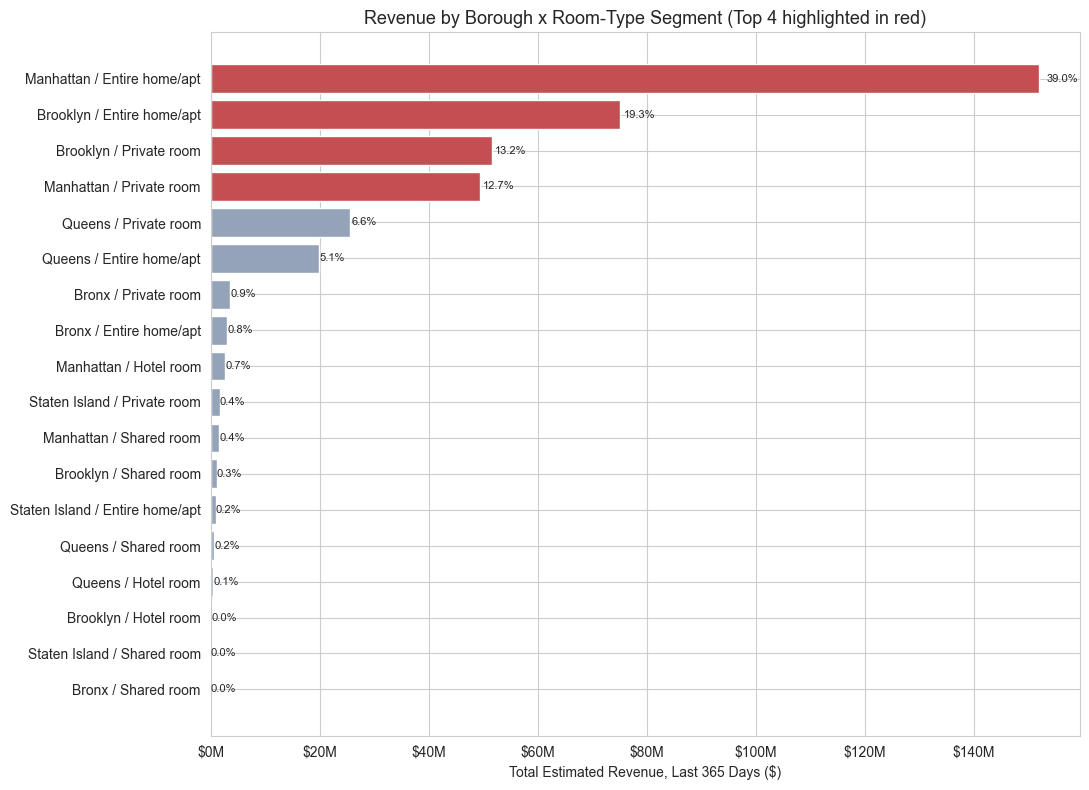

In [19]:
# ==========================================================
# Viz 1 — Revenue Share by Segment (Top 4 vs Rest) + Segment Bar
# 시각화 1 — 세그먼트별 매출 비중 (상위 4개 강조 막대 차트)
# ==========================================================

plot_df = segment.copy()
plot_df["label"] = plot_df["borough"] + " / " + plot_df["room_type"]
plot_df = plot_df.sort_values("total_revenue", ascending=True)
colors = ["#C44E52" if i >= len(plot_df) - 4 else "#94a3b8" for i in range(len(plot_df))]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_df["label"], plot_df["total_revenue"], color=colors)
ax.set_xlabel("Total Estimated Revenue, Last 365 Days ($)")
ax.set_title("Revenue by Borough x Room-Type Segment (Top 4 highlighted in red)", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:,.0f}M"))

for i, v in enumerate(plot_df["total_revenue"]):
    ax.text(v * 1.01, i, f"{plot_df['revenue_share_pct'].iloc[i]:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

#### 4-8. Visualisation — superhost revenue lift in top-4 segments
**English** Visualisation 2 — average revenue, superhost vs regular host, in the top-4 segments  
**한국어** 시각화 2 — 상위 4개 세그먼트에서 슈퍼호스트 vs 일반 호스트 평균 매출

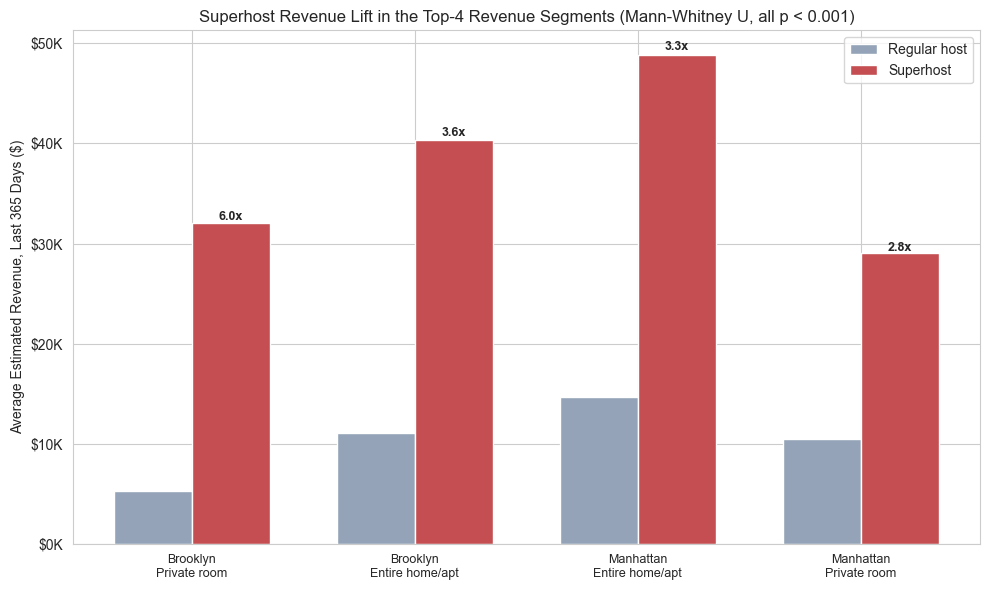

In [20]:
# ==========================================================
# Viz 2 — Superhost vs Regular Average Revenue (Top-4 Segments)
# 시각화 2 — 상위 4개 세그먼트 슈퍼호스트 vs 일반 호스트 매출 비교
# ==========================================================

labels = superhost_effect["borough"] + "\n" + superhost_effect["room_type"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, superhost_effect["regular_mean"], width, label="Regular host", color="#94a3b8")
ax.bar(x + width / 2, superhost_effect["superhost_mean"], width, label="Superhost", color="#C44E52")

for i, row in enumerate(superhost_effect.itertuples()):
    ax.text(i + width / 2, row.superhost_mean * 1.01, f"{row.lift_x:.1f}x", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Average Estimated Revenue, Last 365 Days ($)")
ax.set_title("Superhost Revenue Lift in the Top-4 Revenue Segments (Mann-Whitney U, all p < 0.001)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:,.0f}K"))
ax.legend()

plt.tight_layout()
plt.show()

### Observations
### 관찰 결과

> **English** — What did you notice? Any data quality issue? Anything that needs cleaning?  
> **한국어** — 어떤 점을 발견했는가? 데이터 품질 문제가 있는가? 전처리가 필요한 부분이 있는가?

**Market Concentration (시장 집중도)**
- The top 4 borough × room-type segments (Manhattan/Brooklyn × Entire home/apt & Private
  room) generate **~84% of total estimated market revenue**, out of 18 possible segments.
  Manhattan Entire home/apt alone is **~39%** of the whole market.  
  상위 4개 세그먼트(맨해튼/브루클린 × Entire home/apt·Private room)가 전체 매출의 **약 84%**를
  차지한다(전체 18개 세그먼트 중). 맨해튼 Entire home/apt 하나가 전체 매출의 **약 39%**.
- Kruskal-Wallis confirms borough has a statistically significant effect on revenue for
  Entire home/apt listings (p ≈ 2.6e-11) — the segmentation is not noise.  
  Kruskal-Wallis 검정 결과 Entire home/apt 기준 자치구 간 매출 차이는 통계적으로 유의함
  (p ≈ 2.6e-11) — 세그먼트 차이가 우연이 아니다.

**Revenue Field is Zero-inflated (매출 컬럼의 0값 편중)**
- About **55% of listings with a non-null revenue value report $0** in
  `estimated_revenue_l365d` — i.e. no bookings in the last 12 months. Only ~45% of
  listings are "active" by this measure.  
  매출값이 결측이 아닌 매물 중 **약 55%가 `estimated_revenue_l365d = 0`** — 최근 1년간
  예약이 없었다는 뜻. 이 기준으로 "활성" 매물은 전체의 약 45%뿐.  
- Using a plain `AVG()` over all listings understates how much an *active* host can
  actually earn, so the segment table above reports both `avg_revenue` (all listings)
  and `avg_revenue_active` (active listings only) side by side.  
  전체 평균만 보면 실제 활성 호스트의 매출력을 과소평가하게 되어, 위 세그먼트 테이블에는
  전체 평균과 활성 매물 평균을 함께 표기했다.

**Superhost Effect (슈퍼호스트 효과)**
- Within every one of the top-4 revenue segments, superhosts earn **2.8x–6.0x** more
  than regular hosts on average, and the difference is highly significant in all four
  (Mann-Whitney U, all p < 0.001).  
  상위 4개 매출 세그먼트 전부에서 슈퍼호스트가 일반 호스트보다 평균 **2.8배~6.0배** 더 많은
  매출을 올리며, 4개 세그먼트 모두 통계적으로 매우 유의함(Mann-Whitney U, 전부 p < 0.001).  
- This validates the original superhost-ROI question from a different angle: the effect
  is not just real, it is *concentrated exactly where the market's money already is*.  
  이는 기존의 슈퍼호스트 ROI 질문을 다른 각도에서 검증해준다 — 효과가 실재할 뿐 아니라,
  시장의 매출이 이미 몰려 있는 세그먼트에서 정확히 나타난다.

**Calendar Occupancy is a Weak, Forward-looking Proxy (캘린더 점유율의 한계)**
- `calendar.date` covers a **future** window (`2026-06-14 ~ 2027-06-22`, see Section
  3's date-range check), i.e. days already booked or blocked *going forward* — while
  `estimated_occupancy_l365d` is Airbnb's own **backward**-looking estimate for the
  past 12 months. Correlating the two gives only `r ≈ -0.11` (weak, and even slightly
  negative) — they measure different things, not the same thing measured badly.  
  `calendar.date`는 **미래** 구간(`2026-06-14~2027-06-22`, 3번 섹션의 날짜 범위 확인 참고)을
  담고 있어 앞으로의 예약/차단 여부를 나타내는 반면, `estimated_occupancy_l365d`는 Airbnb가
  계산한 **과거** 1년 점유율이다. 둘의 상관계수는 `r ≈ -0.11`(약하고, 방향도 살짝 음수)에
  불과한데, 이는 같은 것을 잘못 측정한 게 아니라 애초에 **서로 다른 기간을 측정**하기
  때문이다.  
- The weak *negative* direction is itself a plausible signal: hosts with strong past
  occupancy (high demand already) may have less need to keep their calendar wide open
  for new future bookings, while newer/low-demand hosts may leave more future days
  open. This is a hypothesis, not a confirmed causal finding — flagged here for anyone
  extending this analysis.  
  약한 **음(-)의 방향** 자체도 나름의 신호일 수 있다 — 과거 점유율이 이미 높은(수요가
  검증된) 호스트는 굳이 향후 달력을 넓게 열어둘 필요가 적은 반면, 신규·저수요 호스트는
  향후 예약 가능일을 더 많이 열어둘 수 있다. 이는 확정된 인과관계가 아니라 가설이며,
  추후 분석을 확장할 사람을 위해 남겨둔다.  
- **Decision:** treat `calendar_occupancy` as a supplementary/future-facing signal only.
  Use Airbnb's own `estimated_revenue_l365d` / `estimated_occupancy_l365d` as the
  primary metrics for all historical / segmentation analysis.  
  **결정:** `calendar_occupancy`는 보조/미래 지표로만 사용하고, 과거 실적·세분화 분석에는
  Airbnb 자체 지표(`estimated_revenue_l365d`, `estimated_occupancy_l365d`)를 기본으로 쓴다.  

### Cleaning Decisions
### 전처리 결정

- [x] Drop rows with `estimated_revenue_l365d` IS NULL before any revenue analysis
      (already not computable by Airbnb — 30.9% of listings).  
      매출 계산 자체가 불가능한 행(전체의 30.9%)은 매출 분석 전 제외.
- [x] Do **not** drop `estimated_revenue_l365d == 0` rows — they are valid, meaningful
      "inactive listing" signal, not missing data. Report `active_rate` alongside
      revenue instead of silently filtering them out.  
      `revenue == 0`은 결측이 아니라 "비활성 매물"이라는 유효한 정보이므로 제거하지 않고,
      매출과 함께 `active_rate`로 별도 보고한다.
- [x] Use `estimated_revenue_l365d` / `estimated_occupancy_l365d` as the primary metrics;
      keep `calendar_occupancy` only as a secondary, forward-looking cross-check.  
      기본 지표는 Airbnb 자체 추정치를 사용하고, 캘린더 기반 지표는 보조 지표로만 사용.
- [x] Segment by `neighbourhood_group_cleansed` × `room_type` — both are complete
      (no missing values) and directly actionable for resourcing decisions.  
      결측이 없고 실행 가능한 `neighbourhood_group_cleansed`, `room_type` 기준으로 세분화.

---
## 5. Business Question 2 — Growth Trend
## 성장 추이

### Business Question
**English:** For the top revenue segments found in Section 4 (Manhattan and Brooklyn),
how has guest-review activity trended year over year, and is the growth still led by
the same borough?  
**한국어:** 4번 섹션에서 찾은 상위 매출 세그먼트(맨해튼, 브루클린)에서, 연도별 리뷰(수요)
활동은 어떻게 변해왔으며, 그 성장은 여전히 같은 자치구가 주도하고 있는가?

**SQL Technique (Condition 2 — Time-Based Trend):** `reviews` JOIN `listings` →
extract year with the `strftime('%Y', date)` date function → `GROUP BY` borough, year    
**SQL 기법 (조건 2 — Time-Based Trend):** `reviews` JOIN `listings` → `strftime('%Y', date)`
날짜 함수로 연도 추출 → `GROUP BY` 자치구, 연도  

**So-what — English:** Section 4 is a snapshot; this question checks whether that
snapshot is still true tomorrow — and whether the growth story has already shifted.  
**So-what — 한국어:** 4번 섹션은 스냅샷일 뿐이다. 이 질문은 그 스냅샷이 앞으로도 유효한지,
그리고 성장의 중심이 이미 바뀌었는지를 검증한다.

---

### Relevant Columns
### 관련 컬럼

| Column | Table | Why needed | 필요한 이유 |
|--------|-------|------------|------------|
| `date` | reviews | Extract year → time trend | 연도 추출 → 시간 추이 |
| `listing_id` | reviews | Join key to `listings.id` | `listings.id`와 JOIN하는 키 |
| `id` | listings | Join key | 조인 키 |
| `neighbourhood_group_cleansed` | listings | Borough grouping key | 자치구 그룹 기준 |

### EDA

#### 5-1. SQL — Yearly Review Count by Borough
**English** Aggregate review counts by borough x year using JOIN + a date function
(`strftime`) + GROUP BY (the core query for Condition 2).  
**한국어** JOIN + 날짜 함수(strftime) + GROUP BY로 자치구 x 연도별 리뷰 수 집계 (조건 2 핵심 쿼리).

In [21]:
# ==========================================================
# 5-1. SQL — Yearly Review Trend by Borough
# JOIN(reviews + listings) + 날짜 함수(strftime) + GROUP BY(자치구, 연도)
# ==========================================================

conn = sqlite3.connect(DB_PATH)

trend_query = '''
SELECT
    strftime('%Y', r.date)              AS review_year,
    l.neighbourhood_group_cleansed      AS borough,
    COUNT(*)                            AS review_count
FROM reviews AS r
JOIN listings AS l
    ON r.listing_id = l.id
GROUP BY review_year, borough
ORDER BY review_year, borough
'''
trend = pd.read_sql(trend_query, conn)
conn.close()

trend["review_year"] = trend["review_year"].astype(int)
trend_pivot = trend.pivot(index="review_year", columns="borough", values="review_count").fillna(0)
display(trend_pivot)

borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
review_year,,,,,
2009,0.0,20.0,21.0,0.0,0.0
2010,0.0,210.0,180.0,15.0,0.0
2011,0.0,854.0,624.0,27.0,5.0
2012,3.0,1430.0,1418.0,179.0,16.0
2013,24.0,2557.0,2571.0,533.0,31.0
2014,117.0,5036.0,4753.0,1166.0,45.0
2015,267.0,9772.0,9295.0,2468.0,168.0
2016,775.0,16993.0,13863.0,4232.0,387.0
2017,1309.0,23984.0,17359.0,6145.0,565.0


#### 5-2. Data coverage flags — COVID dip and partial current year
**English** Check for the 2020 COVID dip and flag the current year as a partial year
(data only goes through June).  
**한국어** 2020년 코로나 급락, 2026년 부분 연도(데이터가 6월까지만 존재) 여부 확인.

In [22]:
# ==========================================================
# 5-2. Data Coverage Flags — COVID Dip (2020) & Partial Current Year
# 2020년 코로나 급락 및 최신 연도(2026) 부분 데이터 여부 확인
# ==========================================================

last_review_date = pd.to_datetime(reviews["date"]).max()
print(f"Latest review date in dataset (데이터 마지막 리뷰일): {last_review_date.date()}")
print(f"→ {last_review_date.year} only has data through month {last_review_date.month} "
      f"— treat as a PARTIAL year in any YoY comparison.")
print(f"→ {last_review_date.year}년은 {last_review_date.month}월까지 데이터만 존재 — "
      f"연도별 비교 시 부분 연도로 취급해야 함.")

print()
for b in ["Manhattan", "Brooklyn"]:
    drop_2020 = (trend_pivot.loc[2020, b] / trend_pivot.loc[2019, b] - 1) * 100
    print(f"{b:<10} 2019 -> 2020 change (COVID) : {drop_2020:+.1f}%")

Latest review date in dataset (데이터 마지막 리뷰일): 2026-06-22
→ 2026 only has data through month 6 — treat as a PARTIAL year in any YoY comparison.
→ 2026년은 6월까지 데이터만 존재 — 연도별 비교 시 부분 연도로 취급해야 함.

Manhattan  2019 -> 2020 change (COVID) : -59.2%
Brooklyn   2019 -> 2020 change (COVID) : -62.7%


#### 5-3. Statistical check — pre-COVID vs post-COVID growth rate
**English** Use log-linear regression (`linregress`) to estimate growth rates for
pre-COVID (2010-2019) and post-COVID (2021-2025) separately, and test whether each
trend is statistically significant.  
**한국어** 로그-선형 회귀(linregress)로 코로나 이전(2010-2019)과 이후(2021-2025) 성장률을
각각 추정하고, 통계적으로 유의한 추세인지 검정.

In [23]:
# ==========================================================
# 5-3. Log-linear Regression — Annual Growth Rate, Pre vs Post COVID
# 코로나 이전/이후 연평균 성장률 회귀 분석 (성장 추세의 통계적 유의성 검정)
# ==========================================================

def annual_growth_rate(pivot, borough, year_range):
    sub = pivot.loc[year_range[0]:year_range[1], borough]
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub.index, np.log(sub))
    growth_pct = (np.exp(slope) - 1) * 100
    return growth_pct, r_value ** 2, p_value

growth_summary = []
for period_name, year_range in [("Pre-COVID (2010-2019)", (2010, 2019)), ("Post-COVID (2021-2025)", (2021, 2025))]:
    for borough in ["Manhattan", "Brooklyn"]:
        growth_pct, r2, p_value = annual_growth_rate(trend_pivot, borough, year_range)
        growth_summary.append({
            "period": period_name, "borough": borough,
            "annual_growth_pct": growth_pct, "r_squared": r2, "p_value": p_value,
        })

growth_df = pd.DataFrame(growth_summary)
display(growth_df.round(4))

print("\nInterpretation (해석):")
for row in growth_df.itertuples():
    sig = "significant" if row.p_value < 0.05 else "NOT significant"
    sig_kr = "유의함" if row.p_value < 0.05 else "유의하지 않음"
    print(f"  {row.period:<24} {row.borough:<10} {row.annual_growth_pct:+6.1f}%/yr "
          f"(p={row.p_value:.3f}, {sig} / {sig_kr})")

,period,borough,annual_growth_pct,r_squared,p_value
0,Pre-COVID (2010-2019),Manhattan,71.8646,0.9410,0.0000
1,Pre-COVID (2010-2019),Brooklyn,76.5961,0.9632,0.0000
2,Post-COVID (2021-2025),Manhattan,17.0643,0.7989,0.0409
3,Post-COVID (2021-2025),Brooklyn,5.2496,0.1117,0.5826



Interpretation (해석):
  Pre-COVID (2010-2019)    Manhattan   +71.9%/yr (p=0.000, significant / 유의함)
  Pre-COVID (2010-2019)    Brooklyn    +76.6%/yr (p=0.000, significant / 유의함)
  Post-COVID (2021-2025)   Manhattan   +17.1%/yr (p=0.041, significant / 유의함)
  Post-COVID (2021-2025)   Brooklyn     +5.2%/yr (p=0.583, NOT significant / 유의하지 않음)


#### 5-4. Crossover point — when did the growth leader change?
**English** Compute the year Brooklyn started leading Manhattan, and the year
Manhattan reclaimed the lead.  
**한국어** 브루클린이 맨해튼을 앞서기 시작한 연도, 그리고 다시 역전당한 연도를 계산.

In [24]:
# ==========================================================
# 5-4. Crossover Detection — When Did the Growth Leader Change?
# 성장 리더 교체 시점 탐지
# ==========================================================

gap = (trend_pivot["Manhattan"] - trend_pivot["Brooklyn"])
brooklyn_leads = gap[gap < 0]
manhattan_leads_recent = gap[(gap.index >= 2020) & (gap > 0)]

print(f"Brooklyn led Manhattan in review volume from "
      f"{brooklyn_leads.index.min()} to {brooklyn_leads.index.max()}.")
print(f"브루클린이 {brooklyn_leads.index.min()}년부터 {brooklyn_leads.index.max()}년까지 "
      f"리뷰 건수에서 맨해튼을 앞섰다.")
print()
print(f"Manhattan reclaimed the lead starting {manhattan_leads_recent.index.min()} "
      f"(gap = +{gap.loc[manhattan_leads_recent.index.min()]:,.0f} reviews), "
      f"widening to +{gap.loc[2025]:,.0f} by 2025.")
print(f"맨해튼은 {manhattan_leads_recent.index.min()}년부터 다시 앞서기 시작해 "
      f"2025년에는 격차가 +{gap.loc[2025]:,.0f}건으로 벌어졌다.")

Brooklyn led Manhattan in review volume from 2010 to 2023.
브루클린이 2010년부터 2023년까지 리뷰 건수에서 맨해튼을 앞섰다.

Manhattan reclaimed the lead starting 2024 (gap = +3,840 reviews), widening to +7,643 by 2025.
맨해튼은 2024년부터 다시 앞서기 시작해 2025년에는 격차가 +7,643건으로 벌어졌다.


#### 5-5. Visualisation — yearly review trend by borough
**English** Visualisation 1 — yearly review trend by borough (with COVID-dip and
partial-year annotations)  
**한국어** 시각화 1 — 자치구별 연도별 리뷰 추이 (코로나 급락 및 부분 연도 주석 포함)

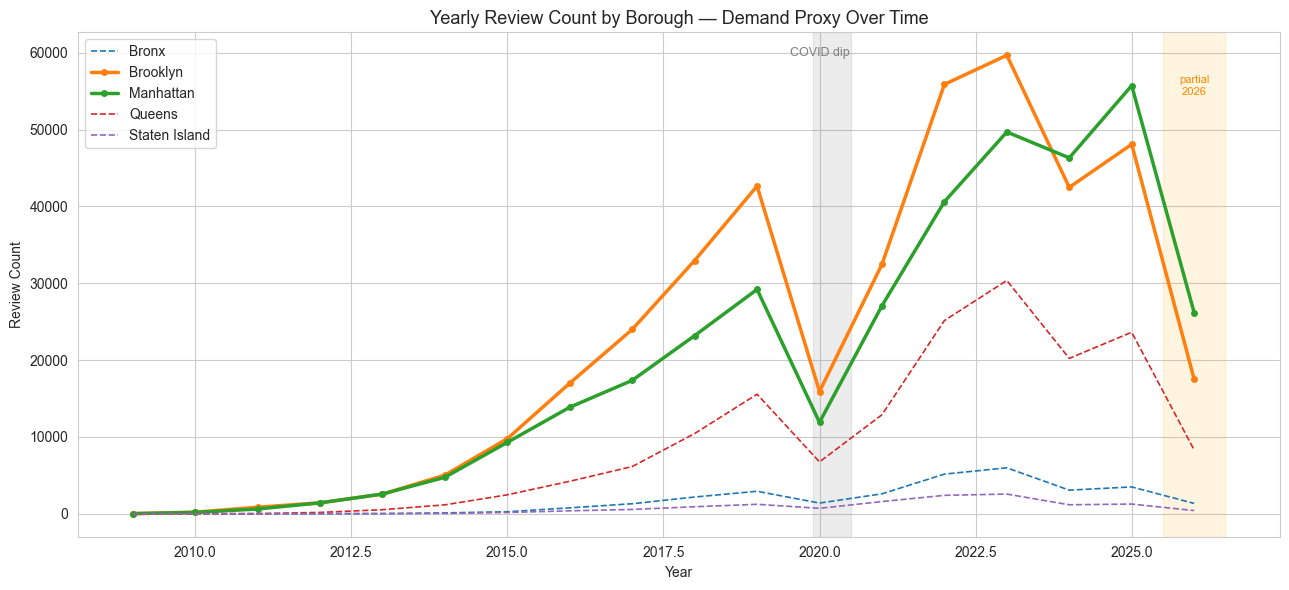

In [25]:
# ==========================================================
# Viz 1 — Yearly Review Trend by Borough (line chart)
# 시각화 1 — 자치구별 연도별 리뷰 추이 선 그래프
# ==========================================================

fig, ax = plt.subplots(figsize=(13, 6))

for borough in trend_pivot.columns:
    style = "-o" if borough in ["Manhattan", "Brooklyn"] else "--"
    lw = 2.5 if borough in ["Manhattan", "Brooklyn"] else 1.2
    ax.plot(trend_pivot.index, trend_pivot[borough], style, linewidth=lw, label=borough, markersize=4)

ax.axvspan(2019.9, 2020.5, color="gray", alpha=0.15)
ax.text(2020, ax.get_ylim()[1] * 0.95, "COVID dip", ha="center", fontsize=9, color="gray")

ax.axvspan(last_review_date.year - 0.5, last_review_date.year + 0.5, color="orange", alpha=0.12)
ax.text(last_review_date.year, ax.get_ylim()[1] * 0.87, f"partial\n{last_review_date.year}",
        ha="center", fontsize=8, color="darkorange")

ax.set_title("Yearly Review Count by Borough — Demand Proxy Over Time", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Review Count")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 5-6. Visualisation — pre vs post-COVID growth rate comparison
**English** Visualisation 2 — pre- vs post-COVID annual growth rate, Manhattan vs Brooklyn  
**한국어** 시각화 2 — 코로나 이전/이후 맨해튼 vs 브루클린 연평균 성장률 비교

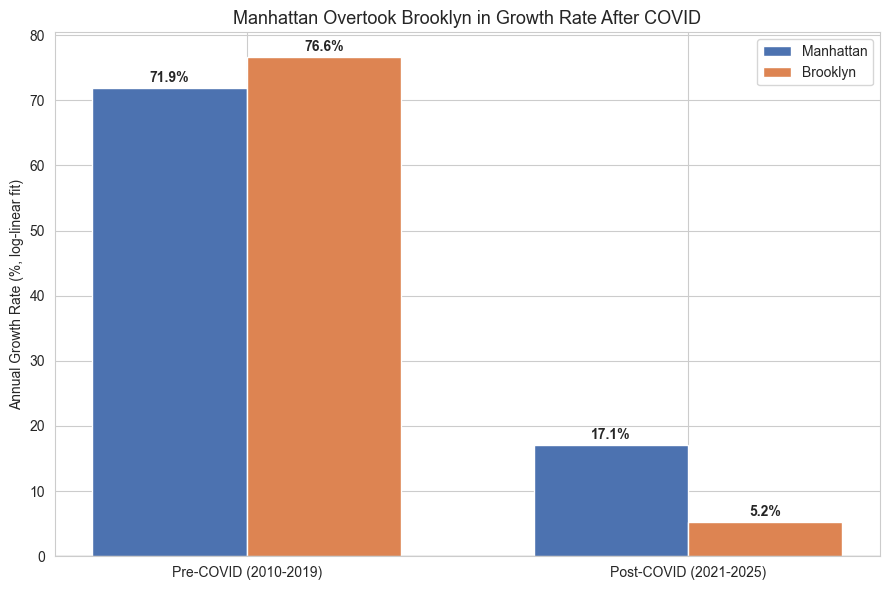

In [26]:
# ==========================================================
# Viz 2 — Pre vs Post-COVID Annual Growth Rate (Manhattan vs Brooklyn)
# 시각화 2 — 코로나 전후 연평균 성장률 비교 막대 차트
# ==========================================================

pivot_growth = growth_df.pivot(index="period", columns="borough", values="annual_growth_pct")
pivot_growth = pivot_growth.loc[["Pre-COVID (2010-2019)", "Post-COVID (2021-2025)"]]

x = np.arange(len(pivot_growth.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width / 2, pivot_growth["Manhattan"], width, label="Manhattan", color="#4C72B0")
ax.bar(x + width / 2, pivot_growth["Brooklyn"], width, label="Brooklyn", color="#DD8452")

for i, (m, b) in enumerate(zip(pivot_growth["Manhattan"], pivot_growth["Brooklyn"])):
    ax.text(i - width / 2, m + 1, f"{m:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + width / 2, b + 1, f"{b:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(pivot_growth.index)
ax.set_ylabel("Annual Growth Rate (%, log-linear fit)")
ax.set_title("Manhattan Overtook Brooklyn in Growth Rate After COVID", fontsize=13)
ax.legend()
ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

### Observations
### 관찰 결과

> **English** — What did you notice about the trend? Any gaps or anomalies?  
> **한국어** — 추이에서 어떤 점을 발견했는가? 공백이나 이상값이 있는가?

**COVID Shock (코로나 충격)**
- Every borough shows a sharp drop in 2020 (Manhattan −59%, Brooklyn −63% vs 2019) —
  a real external shock, not a data quality issue.  
  모든 자치구가 2020년에 급락(맨해튼 −59%, 브루클린 −63%, 2019년 대비)했다 — 데이터 문제가
  아니라 실제 외부 충격(팬데믹)이다.

**Partial Current Year (부분 연도 데이터)**
- The dataset's most recent review is dated in the scrape year, so that year only has
  data for part of the year. Its review count looks like a decline versus the prior
  full year, but this is a **data-coverage artifact**, not a real drop in demand.  
  데이터셋의 가장 최근 리뷰는 스크랩 연도 중간까지만 존재해, 전년 대비 리뷰 수가 줄어든
  것처럼 보이지만 이는 **데이터 수집 기간의 한계**일 뿐 실제 수요 감소가 아니다.

**Growth Leadership Reversal (성장 리더십 역전) — the key finding**
- **Brooklyn led Manhattan** in raw review volume for a full decade (~2014–2023), and
  grew slightly faster pre-COVID (Brooklyn ~76.6%/yr vs Manhattan ~71.9%/yr,
  2010–2019, both p < 0.001).  
  **브루클린이 약 10년(2014~2023년)간** 리뷰 건수에서 맨해튼을 앞섰고, 코로나 이전
  성장률도 브루클린이 근소하게 더 빨랐다(브루클린 ~76.6%/년 vs 맨해튼 ~71.9%/년, 둘 다
  p < 0.001).
- **Since 2024, Manhattan has reclaimed the lead** and the gap is widening
  (+3,840 reviews in 2024, +7,643 in 2025). Post-COVID annual growth is
  **Manhattan ~17.1%/yr (statistically significant, p ≈ 0.04)** vs
  **Brooklyn only ~5.2%/yr (not statistically significant, p ≈ 0.58 — essentially flat)**.  
  **2024년부터는 맨해튼이 다시 앞서기 시작**했고 격차가 벌어지고 있다(2024년 +3,840건,
  2025년 +7,643건). 코로나 이후 연평균 성장률은 **맨해튼 약 17.1%(통계적으로 유의, p≈0.04)**
  vs **브루클린 약 5.2%(유의하지 않음, p≈0.58 — 사실상 정체)**.
- **Business meaning:** the market map from Section 4 (Manhattan = biggest revenue
  segment) is not just a snapshot of the past — Manhattan's demand is *actively
  re-accelerating* while Brooklyn has plateaued. This should be read together with
  Section 6, since (as shown there) Manhattan is also where regulatory risk is
  concentrated.  
  **비즈니스적 의미:** 4번 섹션의 시장 지도(맨해튼 = 최대 매출 세그먼트)는 과거의 스냅샷이
  아니라 지금도 **재가속하고 있는 성장**이다. 반면 브루클린은 정체 상태다. 이는 6번 섹션에서
  보게 될 "리스크도 맨해튼에 집중되어 있다"는 사실과 함께 읽어야 한다.

### Cleaning Decisions
### 전처리 결정

- [x] Exclude the current (partial) year from any year-over-year growth-rate
      calculation; keep it in the raw trend chart but visually flag it.  
      최신(부분) 연도는 연간 성장률 계산에서 제외하고, 추이 차트에는 남기되 시각적으로 표시.
- [x] Keep 2020 in all analyses — it is a genuine external shock, not a data error, and
      removing it would hide a real market event.  
      2020년은 제거하지 않음 — 실제 외부 충격이며, 제거하면 실제 시장 이벤트를 숨기게 됨.  
- [x] Use `strftime('%Y', date)` on `reviews.date` for year extraction — confirmed to
      parse correctly for the full 2009–{latest year} range.  
      `reviews.date`에 대해 `strftime('%Y', date)`로 연도 추출 — 2009년부터 최신 연도까지
      정상 파싱 확인.

---
## 6. Business Question 3 — Risk Distribution
## 리스크 분포

### Business Question
**English:** Among listings that are legally required to register for short-term rental
(`minimum_nights < 30`), what share is unlicensed, and how is that risk distributed by
borough — especially in Manhattan, the segment shown in Sections 4–5 to be both the
biggest and the fastest-reaccelerating?  
**한국어:** 법적으로 단기임대 등록이 필요한 매물(`minimum_nights < 30`) 중 라이선스가
없는 비율은 얼마이고, 그 리스크는 자치구별로 어떻게 분포하는가 — 특히 4~5번 섹션에서
가장 크고 가장 빠르게 재가속하고 있는 것으로 확인된 맨해튼은 어떠한가?

**SQL Technique (Condition 3 — Distribution via Subquery/CTE):** pre-filter with a
`WITH eligible_listings AS (...)` CTE (`minimum_nights < 30`) → `GROUP BY` borough,
license status to see the distribution    
**SQL 기법 (조건 3 — Distribution via Subquery/CTE):** `WITH eligible_listings AS (...)`
CTE로 `minimum_nights < 30` 선필터 → `GROUP BY` 자치구, 라이선스 상태로 분포 확인  

**So-what — English:** Growth (Section 5) looks good on paper, but this question checks
whether part of that growth is built on non-compliant supply that regulators could
force to delist.  
**So-what — 한국어:** 5번 섹션의 성장은 겉보기엔 좋지만, 이 질문은 그 성장의 일부가
규제 당국이 강제 삭제할 수 있는 비인가 매물 위에 쌓여 있는 건 아닌지 확인한다.

---

### Relevant Columns
### 관련 컬럼

| Column | Table | Why needed | 필요한 이유 |
|--------|-------|------------|------------|
| `minimum_nights` | listings | Filters to law-eligible listings (<30 nights) — the CTE's filter condition | 법 적용 대상(<30박) 필터 — CTE의 필터 조건 |
| `license` | listings | Determines registration status (NULL=unlicensed, `Exempt`=exempt, else=licensed) | 등록 여부 판단 (NULL=미등록, `Exempt`=면제, 그 외=등록됨) |
| `neighbourhood_group_cleansed` | listings | Borough-level comparison | 자치구별 비교 |
| `estimated_revenue_l365d` | listings | Sizes the at-risk revenue | 리스크 매출 규모 계산 |

### EDA

#### 6-1. License and eligibility columns — what do the raw values look like?
**English** Check the raw value distribution of `license` and `minimum_nights` —
understand the data before deciding on the CTE filter/classification rules.  
**한국어** `license`, `minimum_nights` 원본 값 분포 확인 — CTE 필터/분류 기준을 정하기 전에
먼저 데이터를 이해한다.

In [42]:
# ==========================================================
# 6-1. License Values & Minimum-Nights Eligibility Check
# license 값 분포 및 minimum_nights<30 대상 비율 확인
# ==========================================================

print("=== `license` value pattern (top 5, incl. NaN) ===")
license_summary = listings["license"].fillna("(missing)").apply(
    lambda x: x if x in ("(missing)", "Exempt") else "OSE-STRREG-#### (has a license number)"
)
display(license_summary.value_counts())

print()
eligible_pct = (listings["minimum_nights"] < 30).mean() * 100
print(f"Listings with minimum_nights < 30 (법 적용 대상 비율) : {eligible_pct:.1f}%")
print(f"  → Most listings (median minimum_nights = "
      f"{listings['minimum_nights'].median():.0f}) are already set up as 30+ night "
      f"stays, which NYC Local Law 18 exempts from registration.")
print(f"  → 대부분 매물(중앙값 {listings['minimum_nights'].median():.0f}박)은 이미 30박 이상으로 "
      f"설정되어 있어 NYC Local Law 18의 등록 의무 대상이 아니다.")

=== `license` value pattern (top 5, incl. NaN) ===


license
(missing)                                 24973
Exempt                                     2956
OSE-STRREG-#### (has a license number)     2330
Name: count, dtype: int64


Listings with minimum_nights < 30 (법 적용 대상 비율) : 18.3%
  → Most listings (median minimum_nights = 30) are already set up as 30+ night stays, which NYC Local Law 18 exempts from registration.
  → 대부분 매물(중앙값 30박)은 이미 30박 이상으로 설정되어 있어 NYC Local Law 18의 등록 의무 대상이 아니다.


#### 6-2. SQL — CTE Filter, then Distribution by Borough × License Status
**English** Pre-filter to `minimum_nights < 30` listings with a CTE, then aggregate
the distribution by borough × license status (the core query for Condition 3).  
**한국어** CTE로 `minimum_nights<30` 매물만 먼저 걸러낸 뒤, 자치구 × 라이선스 상태로
분포를 집계 (조건 3 핵심 쿼리).

In [28]:
# ==========================================================
# 6-2. SQL — CTE (minimum_nights < 30) then GROUP BY Borough x License Status
# WITH 절(CTE)로 등록 대상 매물만 선필터 후 GROUP BY로 분포 확인
# ==========================================================

conn = sqlite3.connect(DB_PATH)

risk_query = '''
WITH eligible_listings AS (
    SELECT *
    FROM listings
    WHERE minimum_nights < 30
)
SELECT
    neighbourhood_group_cleansed AS borough,
    CASE
        WHEN license IS NULL   THEN 'Unlicensed'
        WHEN license = 'Exempt' THEN 'Exempt'
        ELSE 'Licensed'
    END AS license_status,
    COUNT(*)                                        AS listing_count,
    SUM(COALESCE(estimated_revenue_l365d, 0))       AS total_revenue
FROM eligible_listings
GROUP BY borough, license_status
ORDER BY borough, license_status
'''
risk = pd.read_sql(risk_query, conn)
conn.close()

display(risk)

,borough,license_status,listing_count,total_revenue
0,Bronx,Exempt,18,301455.0
1,Bronx,Licensed,120,4223337.0
2,Bronx,Unlicensed,8,161712.0
3,Brooklyn,Exempt,368,20138050.0
4,Brooklyn,Licensed,1164,68946368.0
5,Brooklyn,Unlicensed,25,800920.0
6,Manhattan,Exempt,2353,114284432.0
7,Manhattan,Licensed,266,22796862.0
8,Manhattan,Unlicensed,315,5672465.0
9,Queens,Exempt,166,3102586.0


#### 6-3. Revenue at risk — overall and by borough
**English** Compute the listing-count and revenue share held by unlicensed listings,
overall and by borough.  
**한국어** 미등록(Unlicensed) 매물이 차지하는 매출/매물 비중을 전체 및 자치구별로 계산.

In [29]:
# ==========================================================
# 6-3. Revenue-at-Risk Summary
# 미등록 매물의 매출/매물 비중 — 전체 및 자치구별
# ==========================================================

overall = risk.groupby("license_status")[["listing_count", "total_revenue"]].sum()
overall["listing_share_pct"] = (overall["listing_count"] / overall["listing_count"].sum() * 100).round(1)
overall["revenue_share_pct"] = (overall["total_revenue"] / overall["total_revenue"].sum() * 100).round(1)

print(f"Total eligible listings (등록 대상 매물 전체) : {overall['listing_count'].sum():,} "
      f"({overall['listing_count'].sum() / len(listings) * 100:.1f}% of all listings)")
display(overall)

print()
unlicensed_by_borough = risk[risk["license_status"] == "Unlicensed"].copy()
unlicensed_by_borough["share_of_all_unlicensed_pct"] = (
    unlicensed_by_borough["listing_count"] / unlicensed_by_borough["listing_count"].sum() * 100
).round(1)
print("Where is the unlicensed risk concentrated? (미등록 리스크는 어디에 집중되어 있는가?)")
display(unlicensed_by_borough.sort_values("listing_count", ascending=False))

Total eligible listings (등록 대상 매물 전체) : 5,540 (18.3% of all listings)


,listing_count,total_revenue,listing_share_pct,revenue_share_pct
license_status,,,,
Exempt,2905,137826523.0,52.4,50.4
Licensed,2268,128525022.0,40.9,47.0
Unlicensed,367,7016427.0,6.6,2.6



Where is the unlicensed risk concentrated? (미등록 리스크는 어디에 집중되어 있는가?)


,borough,license_status,listing_count,total_revenue,share_of_all_unlicensed_pct
8,Manhattan,Unlicensed,315,5672465.0,85.8
5,Brooklyn,Unlicensed,25,800920.0,6.8
11,Queens,Unlicensed,19,381330.0,5.2
2,Bronx,Unlicensed,8,161712.0,2.2


#### 6-4. Statistical check — is license status independent of borough?
**English** Chi-square test of independence — check whether license status and
borough are independent, i.e. whether the risk concentration is not just random chance.  
**한국어** 카이제곱 독립성 검정 — 라이선스 상태와 자치구가 서로 독립인지, 즉 리스크 집중이
우연이 아닌지 검정.

In [30]:
# ==========================================================
# 6-4. Chi-square Test of Independence — License Status x Borough
# 라이선스 상태 x 자치구 카이제곱 독립성 검정
# ==========================================================

contingency = risk.pivot(index="borough", columns="license_status", values="listing_count").fillna(0)
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square = {chi2:.1f}, dof = {dof}, p = {p_value:.2e}")
if p_value < 0.05:
    print("→ Statistically significant: license status is NOT independent of borough.")
    print("  Manhattan's over-representation among unlicensed listings is not random noise.")
    print("→ 통계적으로 유의함: 라이선스 상태는 자치구와 독립이 아니다.")
    print("  맨해튼의 미등록 매물 과대 비중은 우연이 아니다.")

license_status,Exempt,Licensed,Unlicensed
borough,,,
Bronx,18.0,120.0,8.0
Brooklyn,368.0,1164.0,25.0
Manhattan,2353.0,266.0,315.0
Queens,166.0,664.0,19.0
Staten Island,0.0,54.0,0.0



Chi-square = 2646.2, dof = 8, p = 0.00e+00
→ Statistically significant: license status is NOT independent of borough.
  Manhattan's over-representation among unlicensed listings is not random noise.
→ 통계적으로 유의함: 라이선스 상태는 자치구와 독립이 아니다.
  맨해튼의 미등록 매물 과대 비중은 우연이 아니다.


#### 6-5. Visualisation — license status share by borough
**English** Visualisation 1 — license status share by borough (100% stacked bar)  
**한국어** 시각화 1 — 자치구별 라이선스 상태 비중 (100% 누적 막대)

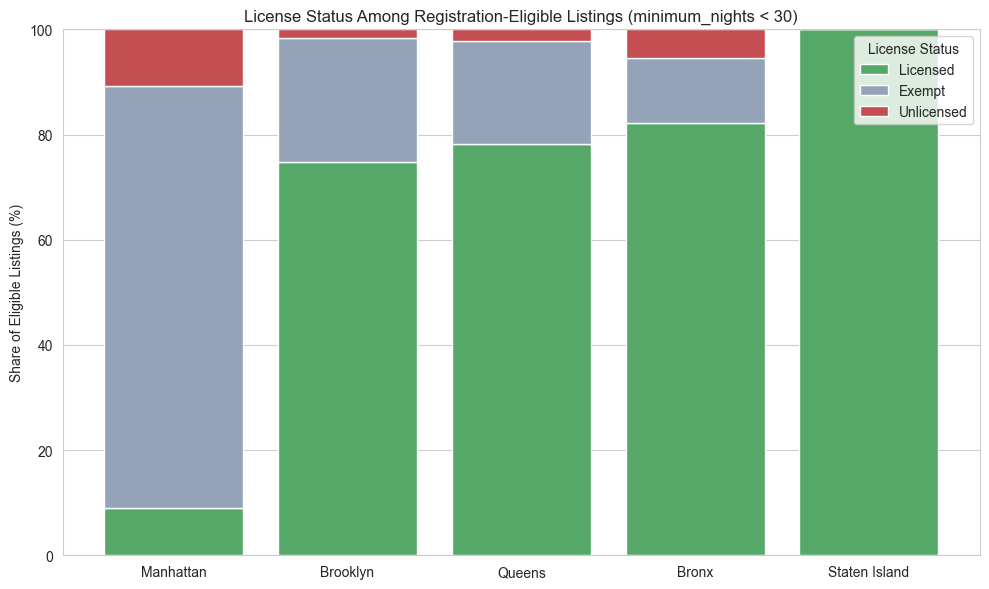

In [31]:
# ==========================================================
# Viz 1 — License Status Share by Borough (100% Stacked Bar)
# 시각화 1 — 자치구별 라이선스 상태 100% 누적 막대 차트
# ==========================================================

share = contingency.div(contingency.sum(axis=1), axis=0) * 100
share = share[["Licensed", "Exempt", "Unlicensed"]]
share = share.loc[contingency.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Licensed": "#55a868", "Exempt": "#94a3b8", "Unlicensed": "#C44E52"}
bottom = np.zeros(len(share))
for status in ["Licensed", "Exempt", "Unlicensed"]:
    ax.bar(share.index, share[status], bottom=bottom, label=status, color=colors[status])
    bottom += share[status].values

ax.set_ylabel("Share of Eligible Listings (%)")
ax.set_title("License Status Among Registration-Eligible Listings (minimum_nights < 30)", fontsize=12)
ax.legend(title="License Status", loc="upper right")

plt.tight_layout()
plt.show()

#### 6-6. Visualisation — unlicensed listing count & revenue by borough
**English** Visualisation 2 — unlicensed listing count and revenue by borough
(highlighting Manhattan's concentration)  
**한국어** 시각화 2 — 자치구별 미등록 매물 수 및 매출 (맨해튼 집중도 강조)

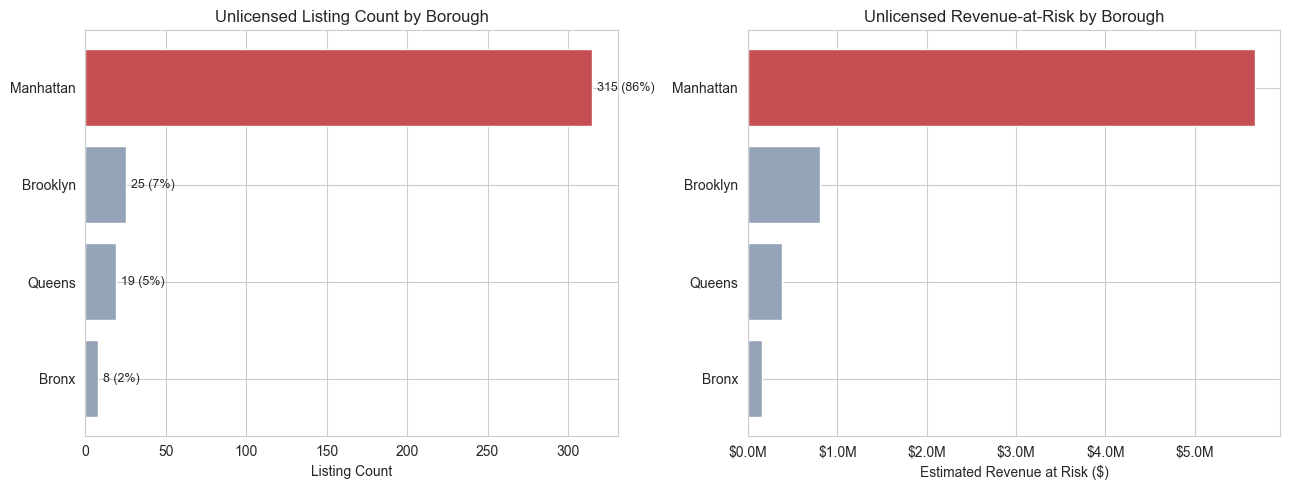

In [32]:
# ==========================================================
# Viz 2 — Unlicensed Listings: Count & Revenue by Borough
# 시각화 2 — 자치구별 미등록 매물 수 및 매출
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ub = unlicensed_by_borough.sort_values("listing_count", ascending=True)
colors = ["#C44E52" if b == "Manhattan" else "#94a3b8" for b in ub["borough"]]

axes[0].barh(ub["borough"], ub["listing_count"], color=colors)
axes[0].set_title("Unlicensed Listing Count by Borough")
axes[0].set_xlabel("Listing Count")
for i, v in enumerate(ub["listing_count"]):
    axes[0].text(v + 3, i, f"{v:,} ({ub['share_of_all_unlicensed_pct'].iloc[i]:.0f}%)", va="center", fontsize=9)

axes[1].barh(ub["borough"], ub["total_revenue"], color=colors)
axes[1].set_title("Unlicensed Revenue-at-Risk by Borough")
axes[1].set_xlabel("Estimated Revenue at Risk ($)")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}M"))

plt.tight_layout()
plt.show()

### Observations
### 관찰 결과

> **English** — What did you notice? Any data quality issue? Anything that needs cleaning?  
> **한국어** — 어떤 점을 발견했는가? 데이터 품질 문제가 있는가? 전처리가 필요한 부분이 있는가?

**Eligibility Filter Matters (등록 대상 필터의 중요성)**
- Only **~18.3%** of all listings (`minimum_nights < 30`) are even subject to NYC's
  short-term rental registration law. The other ~82% are already set up as 30+ night
  stays and are automatically exempt — so this question **must** filter first (the
  CTE), or the "unlicensed" numbers would be wildly overstated.  
  전체 매물 중 **약 18.3%**만 `minimum_nights < 30`으로 NYC 단기임대 등록법 적용 대상이다.
  나머지 약 82%는 이미 30박 이상으로 설정되어 자동 면제 대상이므로, 이 질문은 **반드시**
  먼저 필터링(CTE)해야 하며, 그렇지 않으면 "미등록" 수치가 크게 과대평가된다.  
- `license = 'Exempt'` is a **valid, legal** status (e.g. hotels, or listings that
  qualify for another exemption) — it must be counted separately from a true `NULL`
  (never registered).  
  `license = 'Exempt'`는 **합법적인** 상태(예: 호텔 또는 다른 면제 사유)이므로, 실제
  미등록(`NULL`)과 반드시 구분해서 집계해야 한다.

**Risk is Small in Share, but Highly Concentrated (비중은 작지만 매우 집중됨)**
- Among the 5,540 eligible listings, only **6.6% (367 listings)** are truly unlicensed,
  representing **~$7.0M** in estimated annual revenue (2.6% of eligible-segment revenue).  
  등록 대상 5,540개 매물 중 진짜 미등록은 **6.6%(367개)**뿐이며, 추정 연매출 기준
  **약 $700만**(대상 세그먼트 매출의 2.6%)에 해당한다.  
- But **85.8% of all unlicensed listings are in Manhattan** — the chi-square test
  confirms this concentration is statistically significant (χ² ≈ 2,646, p ≈ 0), not
  random variation across boroughs.  
  하지만 **전체 미등록 매물의 85.8%가 맨해튼**에 있다 — 카이제곱 검정 결과 이 집중은
  통계적으로 유의하며(χ² ≈ 2,646, p ≈ 0) 자치구 간 우연한 변동이 아니다.
- **Business meaning:** the compliance risk sits almost entirely on top of the exact
  segment that Sections 4–5 identified as the biggest *and* fastest-reaccelerating
  revenue driver. Growth and risk are not in different places — they are the same place.  
  **비즈니스적 의미:** 컴플라이언스 리스크는 4~5번 섹션에서 확인한 가장 크고 가장 빠르게
  재가속하는 매출 동력과 거의 같은 자리에 놓여 있다. 성장과 리스크가 다른 곳이 아니라
  **같은 곳**에서 발생하고 있다.

### Cleaning Decisions
### 전처리 결정

- [x] Always filter to `minimum_nights < 30` **before** computing any license-related
      metric — implemented as a CTE so the eligibility rule is explicit and reusable.  
      라이선스 관련 지표는 반드시 `minimum_nights < 30` 필터를 **먼저** 적용 — CTE로
      명시적이고 재사용 가능하게 구현.
- [x] Classify `license` into 3 categories, not 2: `Unlicensed` (NULL), `Exempt`
      (`'Exempt'`), `Licensed` (any registration number) — collapsing `Exempt` into
      either of the other two would misstate the real compliance risk.  
      `license`는 2개가 아닌 3개 범주(`Unlicensed`/`Exempt`/`Licensed`)로 분류 — `Exempt`를
      다른 범주에 합치면 실제 리스크를 왜곡하게 됨.
- [x] Report both listing-count share and revenue share — a segment can be small in
      count but meaningful in dollars (or vice versa).  
      매물 수 비중과 매출 비중을 모두 보고 — 매물 수는 적어도 매출 비중이 클 수 있음.

---
## 7. Business Question 4 — Priority Ranking
## 우선순위 비교

### Business Question
**English:** Among the unlicensed, at-risk revenue identified in Section 6, how
concentrated is it among hosts — and how many hosts would a compliance-outreach
programme need to contact first to resolve 50% / 80% of that risk?  
**한국어:** 6번 섹션에서 확인한 미등록·리스크 매출 중, 얼마나 소수의 호스트에게 집중되어
있으며 — 그 리스크의 50% / 80%를 해소하려면 컴플라이언스 지원 프로그램이 몇 명의
호스트에게 먼저 연락해야 하는가?

**SQL Technique (Condition 4 — Advanced Comparison):** `RANK() OVER (ORDER BY revenue
DESC)` + a running `SUM() OVER (...)` window function to compute each host's revenue
rank and cumulative share    
**SQL 기법 (조건 4 — Advanced Comparison):** `RANK() OVER (ORDER BY revenue DESC)` +
누적 `SUM() OVER (...)` 윈도우 함수로 호스트별 매출 순위·누적 비중 계산  

**So-what — English:** Section 6 quantified the size of the risk; this question turns
that into an executable priority list — exactly what a compliance or account-management
team would act on Monday morning.  
**So-what — 한국어:** 6번 섹션이 리스크의 "규모"를 알려줬다면, 이 질문은 그것을 실행
가능한 "우선순위 리스트"로 바꾼다 — 컴플라이언스·계정관리 팀이 월요일 아침에 바로
실행할 수 있는 결과물이다.

---

### Relevant Columns
### 관련 컬럼

| Column | Table | Why needed | 필요한 이유 |
|--------|-------|------------|------------|
| `host_id` | listings | Host-level aggregation key | 호스트 단위 집계 키 |
| `estimated_revenue_l365d` | listings | Basis for ranking & cumulative share | 순위·누적 비중 계산 대상 |
| `minimum_nights`, `license` | listings | Reuses the "unlicensed/at-risk" subset from Section 6 | Section 6의 "미등록·리스크" 서브셋 재사용 |

### EDA

#### 7-1. SQL — CTE + Window Functions: Host-level Risk Ranking
**English** Rebuild Section 6's unlicensed subset as a CTE, then use `RANK()` and a
running `SUM() OVER` to compute each host's rank and cumulative revenue share
(the core query for Condition 4).  
**한국어** Section 6의 미등록 서브셋을 CTE로 재구성한 뒤, `RANK()`와 누적 `SUM() OVER`로
호스트별 순위와 누적 매출 비중을 계산 (조건 4 핵심 쿼리).

In [33]:
# ==========================================================
# 7-1. SQL — Window Functions: RANK() + Cumulative SUM() OVER
# CTE로 미등록 매물만 추린 뒤, 윈도우 함수로 호스트별 순위·누적 비중 계산
# ==========================================================

conn = sqlite3.connect(DB_PATH)

ranking_query = '''
WITH eligible_listings AS (
    SELECT * FROM listings WHERE minimum_nights < 30
),
unlicensed_listings AS (
    SELECT * FROM eligible_listings WHERE license IS NULL
),
host_revenue AS (
    SELECT
        host_id,
        COUNT(*)                                  AS listing_count,
        SUM(COALESCE(estimated_revenue_l365d, 0)) AS host_revenue
    FROM unlicensed_listings
    GROUP BY host_id
)
SELECT
    host_id,
    listing_count,
    host_revenue,
    RANK() OVER (ORDER BY host_revenue DESC)                          AS revenue_rank,
    SUM(host_revenue) OVER (
        ORDER BY host_revenue DESC
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    )                                                                 AS cumulative_revenue,
    ROUND(
        SUM(host_revenue) OVER (
            ORDER BY host_revenue DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) * 100.0 / SUM(host_revenue) OVER (), 2
    )                                                                 AS cumulative_pct
FROM host_revenue
ORDER BY revenue_rank
'''
host_rank = pd.read_sql(ranking_query, conn)
conn.close()

print(f"Total hosts holding at-risk (unlicensed) revenue : {len(host_rank):,}")
print(f"Total at-risk revenue : ${host_rank['host_revenue'].sum():,.0f}")
display(host_rank.head(15))

Total hosts holding at-risk (unlicensed) revenue : 104
Total at-risk revenue : $7,016,427


,host_id,listing_count,host_revenue,revenue_rank,cumulative_revenue,cumulative_pct
0,714408607,7,471583.0,1,471583.0,6.72
1,563069592,8,390472.0,2,862055.0,12.29
2,703317541,12,328873.0,3,1190928.0,16.97
3,726809828,8,297308.0,4,1488236.0,21.21
4,561031867,5,277756.0,5,1765992.0,25.17
5,546657469,4,252774.0,6,2018766.0,28.77
6,571615601,8,248225.0,7,2266991.0,32.31
7,675221668,3,231099.0,8,2498090.0,35.60
8,712930458,2,169265.0,9,2667355.0,38.02
9,545604918,7,168618.0,10,2835973.0,40.42


#### 7-2. Hosts needed to resolve 50% / 80% of the at-risk revenue
**English** Compute how many hosts it takes for the cumulative share to reach
50% / 80% — an actionable priority cut-off.  
**한국어** 누적 비중이 50%/80%에 도달하는 호스트 수를 계산 — 실행 가능한 우선순위 컷오프.

In [34]:
# ==========================================================
# 7-2. Hosts Needed to Cover 50% / 80% of At-risk Revenue
# 리스크 매출의 50%/80%를 해소하기 위해 필요한 호스트 수
# ==========================================================

total_hosts = len(host_rank)
for target_pct in [50, 80]:
    n = int((host_rank["cumulative_pct"] >= target_pct).idxmax()) + 1
    print(f"Top {n} hosts ({n / total_hosts * 100:.1f}% of {total_hosts} at-risk hosts) "
          f"→ {target_pct}% of at-risk revenue resolved")
    print(f"상위 {n}명({total_hosts}명 중 {n / total_hosts * 100:.1f}%) 호스트에게 연락하면 "
          f"리스크 매출의 {target_pct}%가 해소됨")
    print()

Top 15 hosts (14.4% of 104 at-risk hosts) → 50% of at-risk revenue resolved
상위 15명(104명 중 14.4%) 호스트에게 연락하면 리스크 매출의 50%가 해소됨

Top 35 hosts (33.7% of 104 at-risk hosts) → 80% of at-risk revenue resolved
상위 35명(104명 중 33.7%) 호스트에게 연락하면 리스크 매출의 80%가 해소됨



#### 7-3. Statistical check — Gini coefficient (revenue concentration)
**English** Use the Gini coefficient to quantify how unequally at-risk revenue is
distributed across hosts.  
**한국어** 지니계수로 리스크 매출이 호스트 간에 얼마나 불평등하게 분포되어 있는지 정량화.

In [35]:
# ==========================================================
# 7-3. Gini Coefficient — How Unequal is the At-risk Revenue Distribution?
# 지니계수 — 리스크 매출의 호스트 간 불평등도 정량화
# ==========================================================

def gini_coefficient(values):
    sorted_vals = np.sort(values)
    n = len(sorted_vals)
    cumulative = np.cumsum(sorted_vals)
    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n

gini = gini_coefficient(host_rank["host_revenue"].values)
print(f"Gini coefficient of at-risk revenue across hosts : {gini:.3f}")
print(f"  (0 = perfectly equal, 1 = one host holds everything)")
print(f"  (0 = 완전 평등, 1 = 한 명이 전부 보유)")

# Reference: Gini of the overall (all-listing) host revenue, for comparison
all_host_revenue = (
    listings[listings["estimated_revenue_l365d"] > 0]
    .groupby("host_id")["estimated_revenue_l365d"].sum()
)
gini_all = gini_coefficient(all_host_revenue.values)
print(f"\nFor comparison, Gini coefficient across ALL active hosts (전체 활성 호스트 기준): {gini_all:.3f}")

Gini coefficient of at-risk revenue across hosts : 0.621
  (0 = perfectly equal, 1 = one host holds everything)
  (0 = 완전 평등, 1 = 한 명이 전부 보유)

For comparison, Gini coefficient across ALL active hosts (전체 활성 호스트 기준): 0.625


#### 7-4. Visualisation — Lorenz / Pareto curve of at-risk revenue
**English** Visualisation 1 — host rank vs cumulative revenue share (Pareto/Lorenz
curve), with 50%/80% cut-off markers  
**한국어** 시각화 1 — 호스트 순위 vs 누적 매출 비중 (파레토/로렌츠 곡선), 50%/80% 컷오프 표시

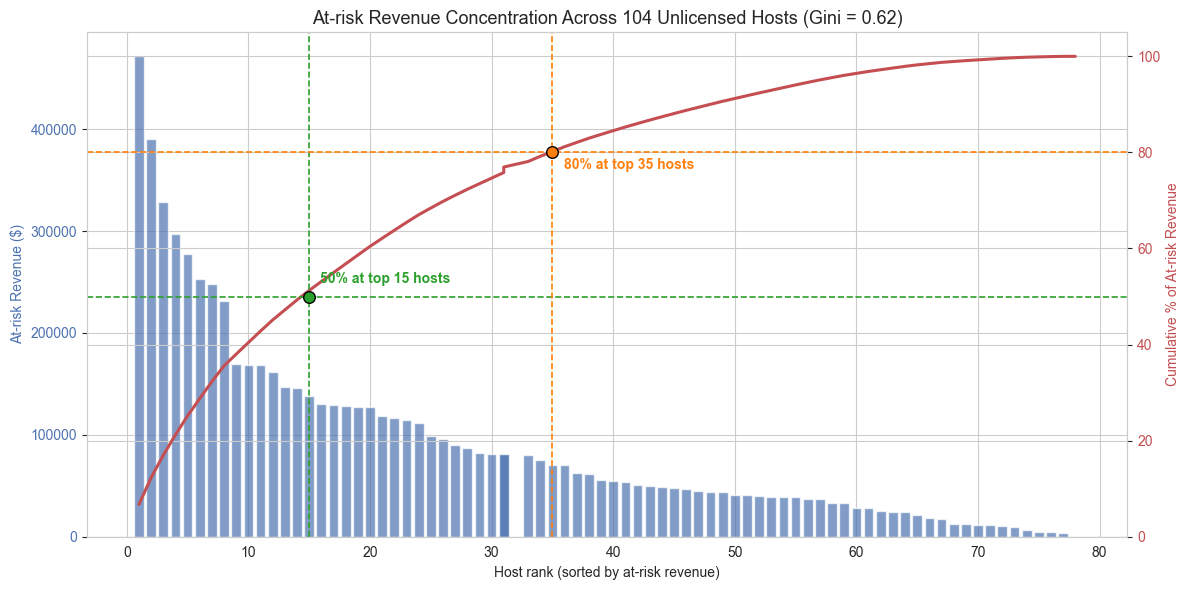

In [43]:
# ==========================================================
# Viz 1 — Pareto / Lorenz Curve: Host Rank vs Cumulative At-risk Revenue Share
# 시각화 1 — 호스트 순위별 누적 매출 비중 (파레토 곡선)
# ==========================================================

n_50 = int((host_rank["cumulative_pct"] >= 50).idxmax()) + 1
n_80 = int((host_rank["cumulative_pct"] >= 80).idxmax()) + 1

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(host_rank["revenue_rank"], host_rank["host_revenue"], color="#4C72B0", alpha=0.7, label="Host revenue")
ax1.set_xlabel("Host rank (sorted by at-risk revenue)")
ax1.set_ylabel("At-risk Revenue ($)", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(host_rank["revenue_rank"], host_rank["cumulative_pct"], color="#C44E52", linewidth=2.2)
ax2.set_ylabel("Cumulative % of At-risk Revenue", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(0, 105)

for target, n, color in [(50, n_50, "#2ca02c"), (80, n_80, "#ff7f0e")]:
    ax2.axhline(target, color=color, linestyle="--", linewidth=1.2)
    ax2.axvline(n, color=color, linestyle="--", linewidth=1.2)
    ax2.scatter([n], [target], color=color, s=70, zorder=5, edgecolor="black")
    ax2.annotate(f"{target}% at top {n} hosts", xy=(n, target), xytext=(8, -12 if target == 80 else 10),
                 textcoords="offset points", fontsize=10, fontweight="bold", color=color)

ax1.set_title(f"At-risk Revenue Concentration Across {total_hosts} Unlicensed Hosts (Gini = {gini:.2f})", fontsize=13)
fig.tight_layout()
plt.show()

#### 7-5. Visualisation — top 15 priority hosts
**English** Visualisation 2 — top 15 priority hosts for outreach  
**한국어** 시각화 2 — 우선 접촉 대상 상위 15개 호스트

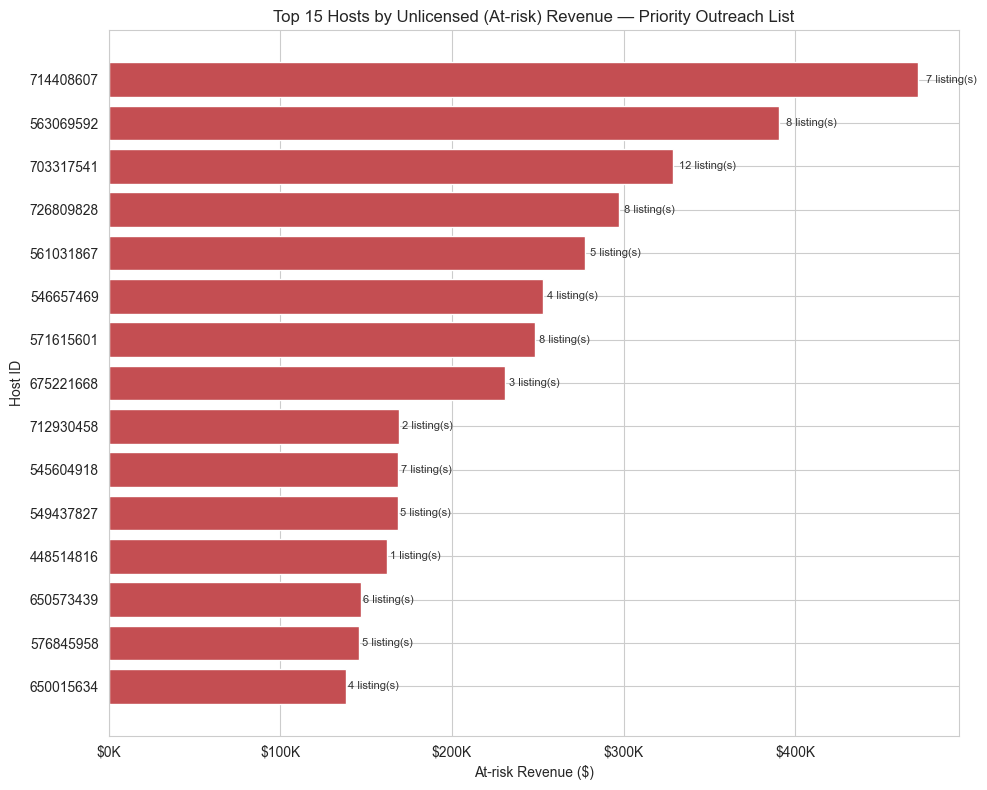

In [37]:
# ==========================================================
# Viz 2 — Top 15 Priority Hosts for Compliance Outreach
# 시각화 2 — 컴플라이언스 우선 접촉 대상 상위 15개 호스트
# ==========================================================

top15 = host_rank.head(15).sort_values("host_revenue", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top15["host_id"].astype(str), top15["host_revenue"], color="#C44E52")

for bar, listings_n in zip(bars, top15["listing_count"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{listings_n} listing(s)", va="center", fontsize=8, color="#333333")

ax.set_xlabel("At-risk Revenue ($)")
ax.set_ylabel("Host ID")
ax.set_title("Top 15 Hosts by Unlicensed (At-risk) Revenue — Priority Outreach List", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:,.0f}K"))

plt.tight_layout()
plt.show()

### Observations
### 관찰 결과

> **English** — What did you notice? Any data quality issue? Anything that needs cleaning?  
> **한국어** — 어떤 점을 발견했는가? 데이터 품질 문제가 있는가? 전처리가 필요한 부분이 있는가?

**Extreme Concentration Among a Small Host Pool (소수 호스트에 대한 극단적 집중)**
- Only **104 hosts** in the entire dataset hold the $7.0M in at-risk (unlicensed)
  revenue found in Section 6.  
  6번 섹션에서 확인한 $700만 규모의 리스크(미등록) 매출은 전체 데이터셋에서 단
  **104명의 호스트**만이 보유하고 있다.
- Just **15 hosts (14.4% of the 104)** account for **50%** of at-risk revenue, and
  **35 hosts (33.7%)** account for **80%**.  
  단 **15명(104명 중 14.4%)**이 리스크 매출의 **50%**를, **35명(33.7%)**이 **80%**를
  차지한다.
- The Gini coefficient for at-risk revenue (**0.62**) is essentially the same as the
  Gini for the overall host market (**0.63**, all active hosts). In other words,
  unlicensed revenue is **not** unusually concentrated compared to the market as a
  whole — it simply mirrors the same "a few large multi-listing hosts earn most of the
  revenue" pattern seen everywhere in this market. That is actually good news
  operationally: the same revenue-rank-based outreach logic used elsewhere in the
  business works here too, with no special-case concentration to design around.  
  리스크 매출의 지니계수(**0.62**)는 전체 호스트 시장의 지니계수(**0.63**, 전체 활성
  호스트 기준)와 거의 같다. 즉 미등록 매출이 시장 전체보다 유별나게 더 집중된 것이
  아니라, "소수의 다물권 대형 호스트가 매출 대부분을 차지한다"는 이 시장 전반의 패턴을
  그대로 반영할 뿐이다. 운영 관점에서는 오히려 좋은 소식인데, 별도의 특수한 집중도
  로직을 설계할 필요 없이 기존에 쓰던 매출 순위 기반 접촉 전략을 그대로 적용하면 되기
  때문이다.

**Business meaning — the story's conclusion (비즈니스적 의미 — 스토리의 결론)**
- The four questions now connect end-to-end: Manhattan/Brooklyn Entire-home & Private-
  room listings drive 84% of revenue (Section 4) → Manhattan's demand is
  re-accelerating fastest (Section 5) → 85.8% of unlicensed risk sits in that same
  Manhattan segment (Section 6) → and just 15–35 hosts control most of that specific
  risk (Section 7).  
  4개 질문이 이제 끝에서 끝까지 연결된다: 맨해튼/브루클린의 Entire home·Private room이
  매출의 84%를 견인(4번) → 맨해튼의 수요가 가장 빠르게 재가속(5번) → 미등록 리스크의
  85.8%가 바로 그 맨해튼 세그먼트에 집중(6번) → 그리고 단 15~35명의 호스트가 그 리스크의
  대부분을 통제(7번).
- **Recommended action:** launch a compliance-registration support programme targeting
  the top ~35 hosts identified here first — this resolves 80% of the identified
  revenue-at-risk with a contact list small enough to execute immediately.  
  **권고 액션:** 위에서 확인한 상위 약 35명의 호스트를 우선 대상으로 한 라이선스 등록
  지원 프로그램을 시작한다 — 즉시 실행 가능한 규모의 연락처 리스트로 확인된 리스크
  매출의 80%를 해소할 수 있다.

### Cleaning Decisions
### 전처리 결정

- [x] Reuse the exact eligibility + license CTE logic from Section 6 (do not
      redefine "unlicensed" differently between sections).  
      6번 섹션과 동일한 등록 대상·라이선스 CTE 로직을 재사용 (섹션마다 "미등록" 정의가
      달라지지 않도록).
- [x] Aggregate to the **host** level (not listing level) before ranking — a host with
      multiple unlicensed listings should be contacted once, not once per listing.  
      순위 계산 전 **호스트** 단위로 집계 — 미등록 매물이 여러 개인 호스트도 한 번만
      접촉하면 되도록.
- [x] Use `RANK()` (not `ROW_NUMBER()`) so that hosts with identical revenue share the
      same rank — relevant since several hosts in this small subset have identical
      single-listing revenue.  
      동일 매출을 가진 호스트가 같은 순위를 갖도록 `ROW_NUMBER()`가 아닌 `RANK()` 사용
      — 이 서브셋에는 동일한 단일 매물 매출을 가진 호스트가 여러 명 존재.

---
## 8. Final Cleaning Decisions
## 최종 전처리 계획

**English** — Once EDA is complete for all 4 questions, consolidate every cleaning
decision into the tables below. This becomes the spec for `pipeline/clean.py`.

**한국어** — 4개 질문의 EDA가 끝나면, 모든 전처리 결정을 아래 표로 정리한다.
이게 `pipeline/clean.py` 구현 기준이 된다.

---

### 8-1. Global rules — applied across all 4 questions
### 전체 질문에 공통 적용되는 규칙

| # | Issue / 이슈 | What was found / 발견한 내용 | Decision / 결정 | `clean.py` code |
|---|-------|-----------------|----------|------------------|
| 1 | `estimated_revenue_l365d` IS NULL | 30.9% of listings — Airbnb could not compute revenue.<br>매물의 30.9% — Airbnb가 매출을 계산하지 못함. | Drop from revenue-based analysis (Q1, Q3, Q4).<br>매출 기반 분석(Q1, Q3, Q4)에서 제외. | `df = df[df["estimated_revenue_l365d"].notna()]` |
| 2 | `estimated_revenue_l365d == 0` | 54.7% of the remaining listings — a real "inactive" signal, not missing data.<br>남은 매물의 54.7% — 결측치가 아니라 실제 "비활성" 신호. | **Keep.** Report `active_rate` alongside averages instead of filtering.<br>**유지.** 필터링 대신 평균과 함께 `active_rate`를 함께 보고. | `df["is_active"] = df["estimated_revenue_l365d"] > 0` |
| 3 | `calendar.date` is a future window | Range is forward-looking (booking calendar for the next year), not historical. Weak correlation (r≈-0.11) with `estimated_occupancy_l365d`.<br>범위가 과거가 아니라 향후 1년의 예약 캘린더(미래 시점). `estimated_occupancy_l365d`와 약한 상관관계(r≈-0.11). | Use as a secondary/forward-looking signal only; primary occupancy metric is Airbnb's own `estimated_occupancy_l365d`.<br>보조/미래 시점 지표로만 사용. 주 점유율 지표는 Airbnb 자체 `estimated_occupancy_l365d`. | n/a (interpretation rule, not a filter) |
| 4 | `license` has 3 real states | `NULL` (unlicensed), `'Exempt'` (legally exempt), or a registration number (licensed). Collapsing to 2 categories misstates risk.<br>`NULL`(미등록), `'Exempt'`(법적 면제), 등록번호(등록됨) 3가지 상태. 2개로 합치면 리스크를 왜곡함. | Always derive a 3-way `license_status` column.<br>항상 3단계 `license_status` 컬럼을 생성. | `CASE WHEN license IS NULL THEN 'Unlicensed' WHEN license='Exempt' THEN 'Exempt' ELSE 'Licensed' END` |
| 5 | `minimum_nights < 30` eligibility | Only ~18.3% of listings are legally subject to the registration law.<br>등록법 적용 대상인 매물은 전체의 약 18.3%뿐. | Always filter to this subset (CTE) before computing any license-risk metric.<br>라이선스 리스크 지표 계산 전 항상 이 서브셋(CTE)으로 먼저 필터링. | `WITH eligible_listings AS (SELECT * FROM listings WHERE minimum_nights < 30)` |

### 8-2. Question-specific filters
### 질문별 전용 필터

| # | Question / 질문 | Issue / 이슈 | Decision / 결정 |
|---|----------|-------|----------|
| 6 | Q1 (Segmentation) | Kruskal-Wallis / Mann-Whitney require raw (non-aggregated) revenue values, not the SQL `GROUP BY` output.<br>Kruskal-Wallis / Mann-Whitney 검정은 SQL `GROUP BY` 결과가 아니라 원본(비집계) 매출 값이 필요. | Pull a second, row-level SQL result specifically for the statistical tests.<br>통계 검정 전용으로 행 단위 SQL 결과를 별도로 추출. |
| 7 | Q2 (Growth Trend) | Current (partial) year is not comparable to full prior years.<br>올해(부분 연도)는 이전 완전 연도와 직접 비교 불가. | Exclude the partial year from YoY / CAGR growth-rate calculations; keep it in trend charts with a visual flag.<br>YoY/CAGR 성장률 계산에서는 부분 연도를 제외하되, 추이 차트에는 시각 표시와 함께 유지. |
| 8 | Q3 (Risk Distribution) | Small expected cell counts in some borough x license_status cells (e.g. Staten Island has 0 unlicensed listings).<br>일부 자치구 x license_status 셀의 기대빈도가 작음 (예: 스태튼아일랜드는 미등록 매물 0건). | Kept in the chi-square test — `scipy.stats.chi2_contingency` handles zero cells; result remains highly significant.<br>카이제곱 검정에 그대로 포함 — `scipy.stats.chi2_contingency`는 0인 셀도 처리 가능하며 결과는 여전히 매우 유의함. |
| 9 | Q4 (Priority Ranking) | Ranking should be host-level, not listing-level.<br>순위는 매물 단위가 아니라 호스트 단위여야 함. | Aggregate `SUM(estimated_revenue_l365d)` by `host_id` inside the CTE before ranking.<br>순위를 매기기 전 CTE 안에서 `host_id`별로 `SUM(estimated_revenue_l365d)`를 집계. |

### 8-3. Decisions NOT taken — and why
### 하지 않기로 결정한 전처리 — 이유 포함

| Issue / 이슈 | Why not cleaned / 처리하지 않은 이유 |
|-------|------------------|
| Removing 2020 (COVID) from the trend | It is a genuine external shock affecting the whole market, not a data-quality problem — removing it would hide a real event.<br>시장 전체에 영향을 준 실제 외부 충격이지 데이터 품질 문제가 아님 — 제거하면 실제 사건을 숨기게 됨. |
| Treating `calendar_occupancy` as the primary occupancy metric | It measures a different (future) time window than `estimated_occupancy_l365d`; using it as primary would silently change what "occupancy" means across questions.<br>`estimated_occupancy_l365d`와 다른(미래) 기간을 측정함 — 주 지표로 쓰면 질문마다 "점유율"의 의미가 조용히 바뀜. |
| Merging `Exempt` into `Licensed` for simplicity | `Exempt` listings never had to register in the first place — merging them would understate genuine compliance risk.<br>`Exempt` 매물은 애초에 등록 의무가 없었음 — 합치면 실제 컴플라이언스 리스크를 과소평가하게 됨. |

> **Notes (참고사항):**
> - Add rows as new decisions are made during EDA.
> - 새로운 전처리 결정이 생기면 행을 추가한다.

---
## 9. Pipeline Implementation Plan
## Pipeline 구현 계획

**English** — EDA is complete. All cleaning decisions have been validated in this notebook.
The next step is to implement them as reusable, testable functions in the `pipeline/` package.

**한국어** — EDA 완료. 모든 전처리 결정이 노트북에서 검증됨. 다음 단계는 `pipeline/` 패키지에서
재사용 가능하고 테스트 가능한 함수로 구현하는 것.

---

### Flow
### 흐름

```
airbnb_business_eda.ipynb  (탐색 · 관찰 · 결정)
        ↓
pipeline/clean.py   (전처리 함수 구현)
        ↓
pipeline/analyze.py (질문별 분석 함수 — SQL 직접 실행)
        ↓
pipeline/visualize.py (차트 함수)
        ↓
main.py             (전체 파이프라인 실행)
```

---

### File Responsibilities
### 파일별 역할

| File | Responsibility | 역할 |
|------|-----------------|------|
| `pipeline/load.py` | Load a table from `airbnb_nyc.sqlite` | SQLite에서 테이블 로드 |
| `pipeline/clean.py` | Apply Section 8 cleaning rules | 8번 전처리 규칙 적용 |
| `pipeline/analyze.py` | Answer Q1–Q4 via SQL; return DataFrame/scalar | Q1~Q4를 SQL로 분석 |
| `pipeline/visualize.py` | Produce and save all charts | 차트 생성 및 저장 |
| `main.py` | Orchestrate load → clean → analyze → visualize | 전체 파이프라인 순서 실행 |

### SQL Technique Map (per the 4 required conditions)
### SQL 기법 매핑 (요구 조건 4가지 기준)

| Question / 질문 | Category / 분류 | SQL Technique Used / 사용된 SQL 기법 |
|----------|----------|---------------------|
| Q1 — Market Segmentation | Aggregation and Mapping | `JOIN` (listings + calendar subquery) + `GROUP BY` (borough, room_type) + `SUM`/`AVG`/`COUNT`<br>listings와 calendar 서브쿼리를 `JOIN`, 자치구·룸타입으로 `GROUP BY` 후 `SUM`/`AVG`/`COUNT` 집계 |
| Q2 — Growth Trend | Time-Based Trend | `JOIN` (reviews + listings) + `strftime('%Y', date)` date function + `GROUP BY` (borough, year)<br>reviews와 listings를 `JOIN`, 날짜 함수 `strftime('%Y', date)`로 연도 추출 후 자치구·연도로 `GROUP BY` |
| Q3 — Risk Distribution | Distribution via Subquery/CTE | `WITH eligible_listings AS (...)` CTE filter, then `GROUP BY` (borough, license_status)<br>`WITH eligible_listings AS (...)` CTE로 먼저 필터링한 뒤 자치구·라이선스 상태로 `GROUP BY` |
| Q4 — Priority Ranking | Advanced Comparison | `RANK() OVER (...)` + cumulative `SUM() OVER (...)` window functions<br>`RANK() OVER (...)`와 누적 `SUM() OVER (...)` 윈도우 함수 사용 |

### Data Limitations
### 데이터 한계 (포트폴리오 명시 사항)

- `estimated_revenue_l365d` is missing for 30.9% of listings and is $0 for another
  ~55% of the remainder — the revenue figures in this notebook describe roughly the
  **top ~30–45% most active** listings, not the full inventory.  
  `estimated_revenue_l365d`는 전체의 30.9%가 결측이고, 나머지 중 약 55%는 $0이다 — 이
  노트북의 매출 수치는 전체 재고가 아니라 **가장 활성화된 상위 약 30~45%** 매물을
  중심으로 설명한다.
- `calendar.date` is a forward-looking booking window (captured at scrape time), so it
  cannot be used as a historical occupancy measure — only Airbnb's own
  `estimated_occupancy_l365d` is used for that purpose.  
  `calendar.date`는 스크랩 시점 기준 미래 예약 구간이라 과거 점유율 측정에 쓸 수 없다 —
  과거 점유율은 Airbnb 자체 지표(`estimated_occupancy_l365d`)만 사용한다.
- The current (most recent) year in `reviews`/`calendar` is a **partial year**
  (data ends mid-year) and is excluded from all year-over-year growth calculations.  
  `reviews`/`calendar`의 최신 연도는 **부분 연도**(연중까지만 데이터 존재)이며, 모든
  연간 성장률 계산에서 제외했다.
- License-risk figures (Section 6–7) apply only to the ~18.3% of listings with
  `minimum_nights < 30` — the analysis intentionally does not claim anything about
  the other ~82% of listings, which are exempt by design.  
  라이선스 리스크 수치(6~7번 섹션)는 `minimum_nights < 30`인 약 18.3%의 매물에만
  적용된다 — 나머지 약 82%는 설계상 면제 대상이므로 분석 대상에서 의도적으로 제외했다.